In [ ]:
# Cell 1: Imports and Drive Mount
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Libraries loaded and Drive mounted.")

Mounted at /content/drive
✅ Libraries loaded and Drive mounted.


In [ ]:
# Cell 2: Setup Data Directories
base_dir = '/content/drive/MyDrive/Robust_MHCNNFD_Dataset'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Quick check to ensure the folders exist
print("Train path exists:", os.path.exists(train_dir))
print("Val path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

Train path exists: True
Val path exists: True
Test path exists: True


In [ ]:
# Cell 3: Count Images to Verify Dataset Integrity
import os

# Create a dictionary of our splits for easy looping
splits = {
    'TRAIN': train_dir,
    'VAL': val_dir,
    'TEST': test_dir
}

grand_total = 0

print("📊 DATASET IMAGE COUNT AUDIT")
print("=" * 60)

for split_name, split_path in splits.items():
    print(f"\n📂 SPLIT: {split_name}")

    if not os.path.exists(split_path):
        print(f"  [ERROR] Path does not exist: {split_path}")
        continue

    sub_total = 0
    # Get all class folders, sorted alphabetically
    class_folders = sorted(os.listdir(split_path))

    for cls in class_folders:
        cls_path = os.path.join(split_path, cls)

        # Only process directories (ignores stray files like .DS_Store)
        if os.path.isdir(cls_path):
            # Count only files (ignores hidden colab folders like .ipynb_checkpoints)
            num_images = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])

            # Print formatted output
            print(f"  {cls:<35} | Total: {num_images:>5}")
            sub_total += num_images

    print(f"  {'-'*35}-+-------------")
    print(f"  {'SUB-TOTAL':<35} | Total: {sub_total:>5}")
    grand_total += sub_total

print("=" * 60)
print(f"✅ GRAND TOTAL IMAGES: {grand_total}")
if grand_total == 25935:
    print("🟢 VERIFICATION PASSED: The dataset is 100% complete!")
else:
    print(f"🔴 WARNING: Expected 25,935 images, but found {grand_total}.")

📊 DATASET IMAGE COUNT AUDIT

📂 SPLIT: TRAIN
  Evening_Fire_Incident_aug_img       | Total:  5190
  Evening_Forest_Condition_aug_img    | Total:  5185
  Pre-_Evening_Fire_Incident_aug_img  | Total:  5185
  Pre-_Evening_Forest_Condition_aug_img | Total:  5185
  ------------------------------------+-------------
  SUB-TOTAL                           | Total: 20745

📂 SPLIT: VAL
  Evening_Fire_Incident_aug_img       | Total:   645
  Evening_Forest_Condition_aug_img    | Total:   650
  Pre-_Evening_Fire_Incident_aug_img  | Total:   650
  Pre-_Evening_Forest_Condition_aug_img | Total:   650
  ------------------------------------+-------------
  SUB-TOTAL                           | Total:  2595

📂 SPLIT: TEST
  Evening_Fire_Incident_aug_img       | Total:   650
  Evening_Forest_Condition_aug_img    | Total:   645
  Pre-_Evening_Fire_Incident_aug_img  | Total:   650
  Pre-_Evening_Forest_Condition_aug_img | Total:   650
  ------------------------------------+-------------
  SUB-TOTAL         

In [ ]:
# Cell 4: Data Generators (Loading the Images)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the Generator (Rescaling pixels to 0-1)
datagen = ImageDataGenerator(rescale=1./255)

# Define Batch Size and Target Image Size
BATCH_SIZE = 32
IMG_SIZE = (256, 256) # Mandatory for your 4-class Model 1

print("Loading Training Data...")
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Tells Keras to use 4 classes
    shuffle=True # Shuffle only training data for better learning
)

print("\nLoading Validation Data...")
val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Testing Data...")
test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Verify Class Indices
print("\nClass Mapping:", train_gen.class_indices)

Loading Training Data...
Found 20745 images belonging to 4 classes.

Loading Validation Data...
Found 2595 images belonging to 4 classes.

Loading Testing Data...
Found 2595 images belonging to 4 classes.

Class Mapping: {'Evening_Fire_Incident_aug_img': 0, 'Evening_Forest_Condition_aug_img': 1, 'Pre-_Evening_Fire_Incident_aug_img': 2, 'Pre-_Evening_Forest_Condition_aug_img': 3}


In [ ]:
# Cell 5: Build Model 1 (4-Class Version)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense

def build_model1_4class():
    # Input Layer matching your Generator's target size (256x256)
    inputs = Input(shape=(256, 256, 3))

    # Conv Block 1
    x = Conv2D(32, (3, 3), padding='valid', activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Conv Block 2
    x = Conv2D(48, (3, 3), padding='valid', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Conv Block 3
    x = Conv2D(56, (3, 3), padding='valid', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Conv Block 4 (with 10% Dropout)
    x = Conv2D(64, (3, 3), padding='valid', activation='relu')(x)
    x = Dropout(0.1)(x)

    # Conv Block 5
    x = Conv2D(32, (3, 3), padding='valid', activation='relu')(x)

    # Flattening Head
    x = GlobalAveragePooling2D()(x)

    # Fully Connected (Dense) Layers
    x = Dense(64, activation='selu')(x)
    x = Dense(56, activation='selu')(x)
    x = Dense(32, activation='selu')(x)

    # Output Layer (4 Nodes for 4 Classes, Softmax Activation)
    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="MHCNNFD_Model1_4Class")
    return model

# 1. Instantiate the model
model = build_model1_4class()

# 2. Print the summary to verify
model.summary()

Model: "MHCNNFD_Model1_4Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 48)   │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 56)     │        24,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,508 (380.89 KB)

 Trainable params: 97,508 (380.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 6: Compile and Train the Model (Robust Checkpointing Edition)
import tensorflow as tf
import os
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# 1. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Set up Directories & Callbacks
# Let's put all these files in a dedicated folder on your Drive to keep it clean
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
os.makedirs(save_folder, exist_ok=True)

# Goal 1 & 2: Prefix 'Robust_MHCNNFD_mixedDataset' and save EVERY epoch
# The {epoch:02d} creates a numbered file for each epoch automatically
checkpoint_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_{epoch:02d}_ValAcc_{val_accuracy:.4f}.keras')

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=False,   # False to save EVERY epoch
    save_weights_only=False, # Saves the full model architecture + weights
    mode='max',
    verbose=1
)

# Learning Rate Reducer (helps model if it gets stuck)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Goal 3: CSVLogger for flawless graph generation later
# This writes your exact accuracy and loss numbers to a spreadsheet every epoch
csv_log_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv')
csv_logger = CSVLogger(csv_log_path, append=True)

# Combine all callbacks
callbacks_list = [checkpoint, reduce_lr, csv_logger]

# 3. Train the Model
EPOCHS = 40 # Set to 40

print("🚀 Starting Training with Advanced Logging...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

🚀 Starting Training with Advanced Logging...
Epoch 1/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5017 - loss: 0.9543 
Epoch 1: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_01_ValAcc_0.5349.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_01_ValAcc_0.5349.keras
649/649 ━━━━━━━━━━━━━━━━━━━━ 9399s 14s/step - accuracy: 0.6072 - loss: 0.7953 - val_accuracy: 0.5349 - val_loss: 1.0846 - learning_rate: 0.0010
Epoch 2/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.7490 - loss: 0.6035
Epoch 2: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_02_ValAcc_0.8050.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_02_ValAcc_0.8050.keras
649/649 ━━━━━━━━━━━━━━━━━━━━ 335s 516ms/step - accur

In [ ]:
# Cell: RESUME TRAINING FROM EPOCH 25
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# 1. Load latest complete model (Epoch 25)
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
latest_model_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_25_ValAcc_0.9969.keras')
model = load_model(latest_model_path)
print(f"✅ Loaded: {latest_model_path}")

# 2. Rebuild generators (exact same config)
datagen = ImageDataGenerator(rescale=1./255)
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_gen = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen = datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# 3. Same callbacks (CSV appends automatically)
checkpoint_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_{epoch:02d}_ValAcc_{val_accuracy:.4f}.keras')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=False, save_weights_only=False, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
csv_logger = CSVLogger(os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv'), append=True)
callbacks_list = [checkpoint, reduce_lr, csv_logger]

# 4. Resume (set initial_epoch=25, total 40 epochs → 15 left)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,                    # Total epochs
    initial_epoch=25,             # Start from epoch 26
    callbacks=callbacks_list
)
print("🎉 Training completed!")

✅ Loaded: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_25_ValAcc_0.9969.keras
Found 20745 images belonging to 4 classes.
Found 2595 images belonging to 4 classes.
Epoch 26/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9974 - loss: 0.0084 
Epoch 26: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_26_ValAcc_0.9985.keras

Epoch 26: finished saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_26_ValAcc_0.9985.keras
649/649 ━━━━━━━━━━━━━━━━━━━━ 7612s 12s/step - accuracy: 0.9976 - loss: 0.0071 - val_accuracy: 0.9985 - val_loss: 0.0056 - learning_rate: 4.0000e-05
Epoch 27/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9986 - loss: 0.0060 
Epoch 27: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_27_ValAcc_0.9985.keras

Epoch 27: finished saving mo

In [ ]:
# Cell: RESUME FROM EPOCH 31 (Corrected)
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# 1. Load LATEST complete model (Epoch 31 - 99.92% val acc)
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
latest_model_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_31_ValAcc_0.9992.keras')
model = load_model(latest_model_path)
print(f"✅ Loaded: {latest_model_path}")

# 2. Generators (unchanged)
datagen = ImageDataGenerator(rescale=1./255)
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
train_gen = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen = datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# 3. Same callbacks (identical setup)
checkpoint_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_{epoch:02d}_ValAcc_{val_accuracy:.4f}.keras')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=False, save_weights_only=False, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
csv_logger = CSVLogger(os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv'), append=True)
callbacks_list = [checkpoint, reduce_lr, csv_logger]

# 4. Resume from epoch 31 → continues as Epoch 32/40
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,           # Total target
    initial_epoch=31,    # Resume from here (starts Epoch 32)
    callbacks=callbacks_list
)
print("🎉 Training completed!")

✅ Loaded: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_31_ValAcc_0.9992.keras
Found 20745 images belonging to 4 classes.
Found 2595 images belonging to 4 classes.
Epoch 32/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9985 - loss: 0.0055 
Epoch 32: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_32_ValAcc_0.9988.keras

Epoch 32: finished saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_32_ValAcc_0.9988.keras
649/649 ━━━━━━━━━━━━━━━━━━━━ 7370s 11s/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9988 - val_loss: 0.0036 - learning_rate: 4.0000e-05
Epoch 33/40
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9990 - loss: 0.0039 
Epoch 33: saving model to /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_33_ValAcc_0.9985.keras

Epoch 33: finished saving mo

In [ ]:
# Cell 7: Evaluate the Best Model and Visualize Results
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# 1. VISUALIZE TRAINING HISTORY FROM CSV
# This allows you to plot graphs even if Colab restarted!
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
csv_log_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv')

if os.path.exists(csv_log_path):
    history_df = pd.read_csv(csv_log_path)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_df['epoch'], history_df['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history_df['epoch'], history_df['val_accuracy'], label='Val Accuracy', marker='o')
    plt.title('Model 1 Accuracy (Robust Dataset)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history_df['epoch'], history_df['loss'], label='Train Loss', marker='o')
    plt.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o')
    plt.title('Model 1 Loss (Robust Dataset)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Could not find CSV log at {csv_log_path}")


# 2. FIND AND LOAD THE BEST MODEL
print("\n🔍 Searching for the best saved model...")
model_files = glob.glob(os.path.join(save_folder, '*.keras'))

if not model_files:
    print("❌ No .keras files found in the save folder.")
else:
    # Sort files to find the one with the highest ValAcc in the filename
    best_model_path = sorted(model_files, key=lambda x: float(x.split('ValAcc_')[-1].replace('.keras', '')), reverse=True)[0]
    print(f"✅ Found Best Model: {os.path.basename(best_model_path)}")

    print("⏳ Loading model into memory...")
    best_model = load_model(best_model_path)

    # 3. EVALUATE ON TEST SET
    print("\n🧪 Evaluating on the locked TEST set...")
    # Reset generator to ensure predictions line up with true labels
    test_gen.reset()

    test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
    print(f"\n🏆 FINAL TEST ACCURACY: {test_acc:.4f}")

    # 4. CONFUSION MATRIX & CLASSIFICATION REPORT
    print("\n📊 Generating detailed metrics...")
    test_gen.reset()
    predictions = best_model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    # Print Report
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels))

    # Plot Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix - Model 1')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    # Rotate x labels slightly so folder names don't overlap
    plt.xticks(rotation=45, ha='right')
    plt.show()

In [ ]:
#check what files are saved

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Libraries loaded and Drive mounted.")

Mounted at /content/drive
✅ Libraries loaded and Drive mounted.


In [ ]:
import os
from pathlib import Path

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

print("Folder exists:", os.path.exists(save_folder))
print("Folder:", save_folder)
print()

# List everything in the folder
items = sorted(os.listdir(save_folder))
print("All items:")
for name in items:
    full_path = os.path.join(save_folder, name)
    kind = "DIR " if os.path.isdir(full_path) else "FILE"
    size_mb = os.path.getsize(full_path) / (1024 * 1024) if os.path.isfile(full_path) else 0
    print(f"{kind} | {name} | {size_mb:.2f} MB")

print("\nOnly checkpoint files (.keras):")
ckpts = sorted(
    [f for f in items if f.endswith('.keras') and 'Epoch_' in f]
)
for f in ckpts:
    print(f)

print("\nCSV log:")
csv_file = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv')
print(csv_file, "=>", os.path.exists(csv_file))

Folder exists: True
Folder: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs

All items:
FILE | Robust_MHCNNFD_mixedDataset_Epoch_01_ValAcc_0.5349.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_02_ValAcc_0.8050.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_03_ValAcc_0.8620.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_04_ValAcc_0.8913.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_05_ValAcc_0.9106.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_06_ValAcc_0.8705.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_07_ValAcc_0.8967.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_08_ValAcc_0.6805.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_09_ValAcc_0.8886.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_10_ValAcc_0.8906.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_11_ValAcc_0.9584.keras | 1.19 MB
FILE | Robust_MHCNNFD_mixedDataset_Epoch_12_ValAcc_0.9148.keras | 1.19 MB
FILE | Robust

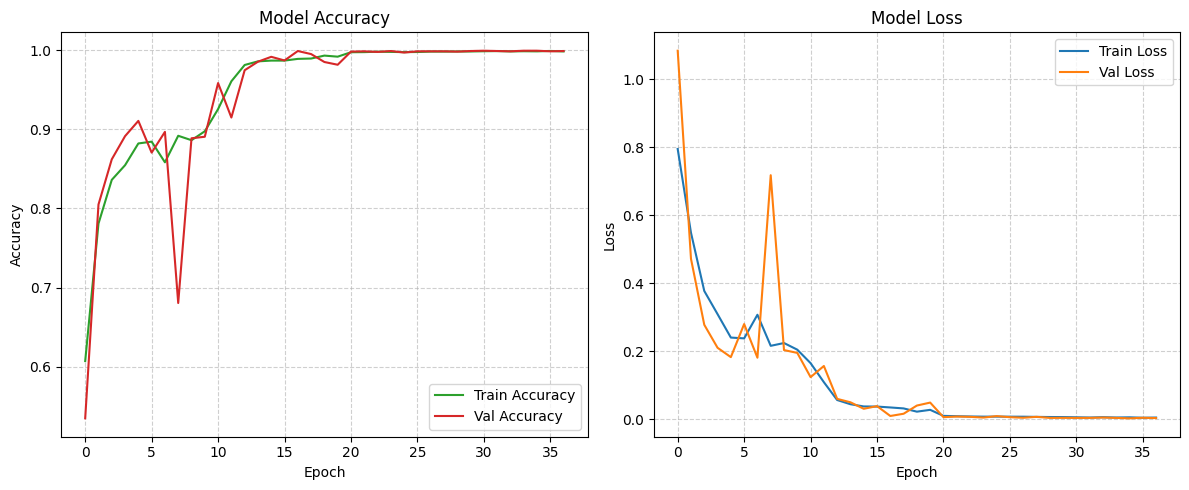

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the history
log_path = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_History.csv'
history_df = pd.read_csv(log_path)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy', color='#2ca02c')
plt.plot(history_df['val_accuracy'], label='Val Accuracy', color='#d62728')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss', color='#1f77b4')
plt.plot(history_df['val_loss'], label='Val Loss', color='#ff7f0e')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

📊 Loaded 37 epochs from CSV


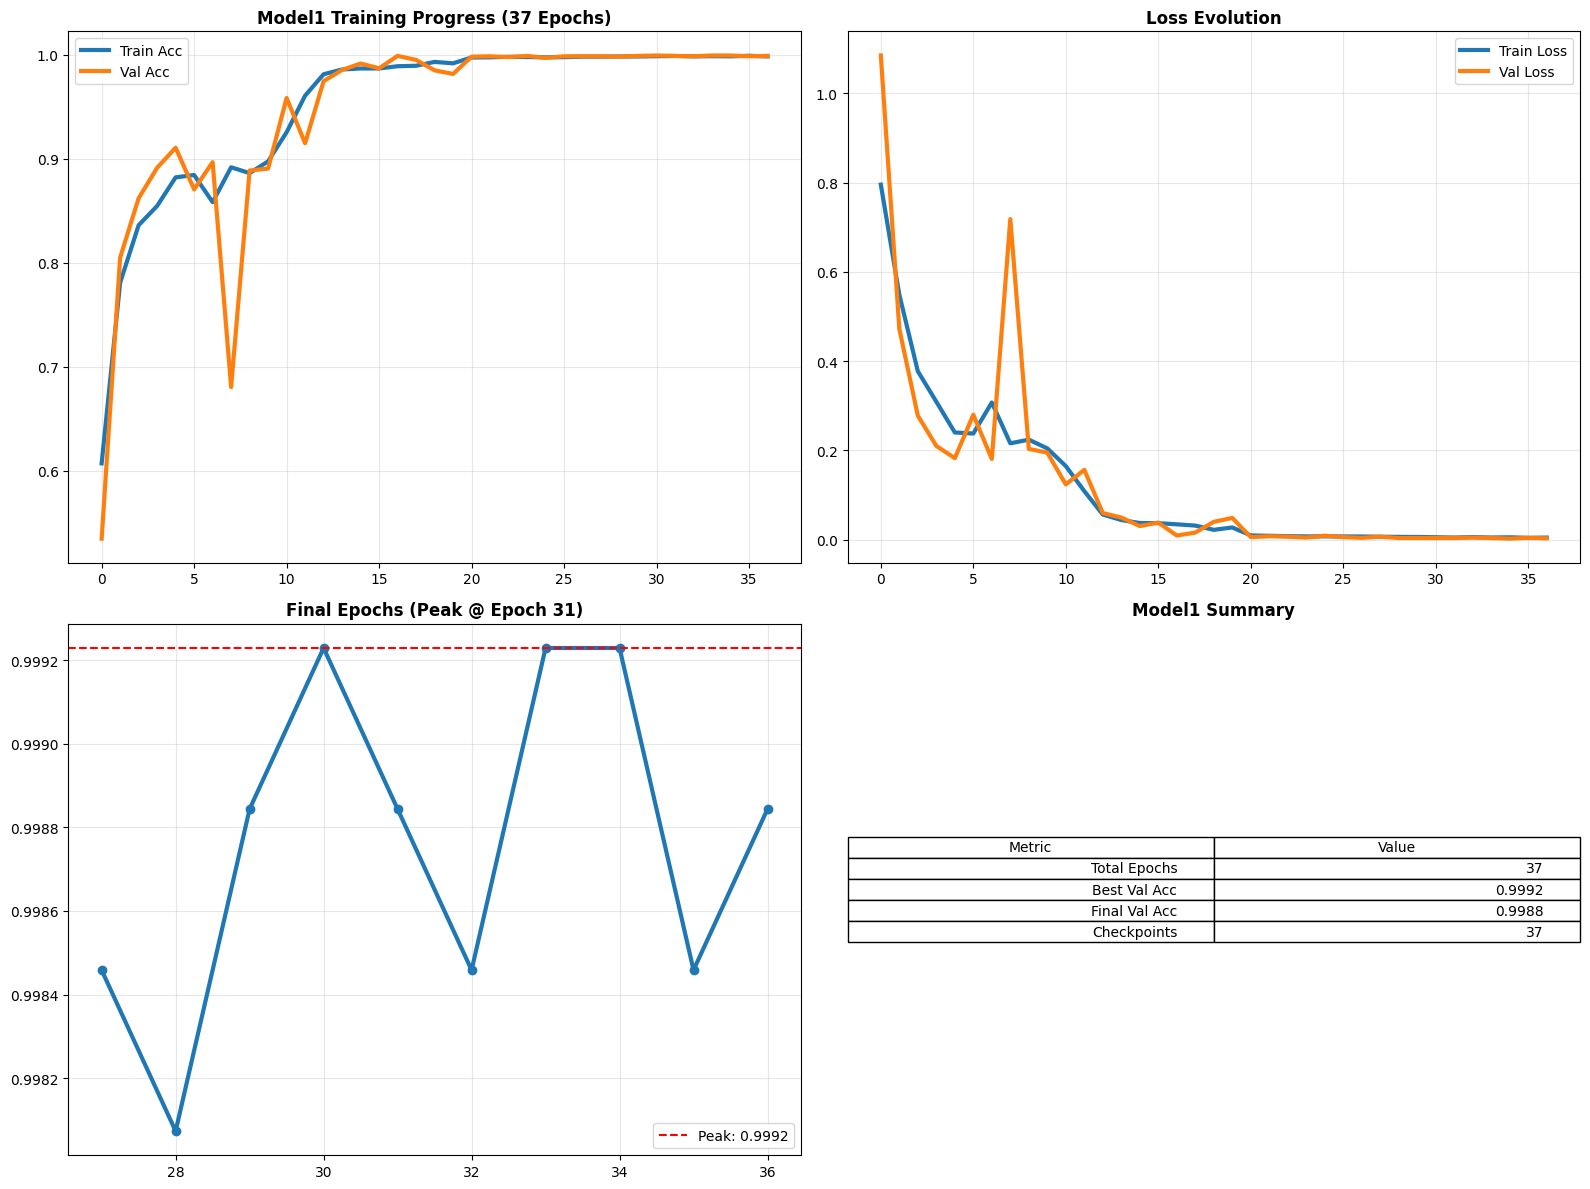

✅ SAVED: Model1_CompleteAnalysis.png & Model1_Summary.json
Peak accuracy: 0.9992 @ Epoch 31


In [ ]:
at.

Test folder: /content/drive/MyDrive/Robust_MHCNNFD_Dataset/test
Classes in test: ['Evening_Forest_Condition_aug_img', 'Pre-_Evening_Forest_Condition_aug_img', 'Pre-_Evening_Fire_Incident_aug_img', 'Evening_Fire_Incident_aug_img']
Found 2595 images belonging to 4 classes.
🔮 Predicting on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 1642s 20s/step
🧪 Test Accuracy: 0.9985 (99.85%)


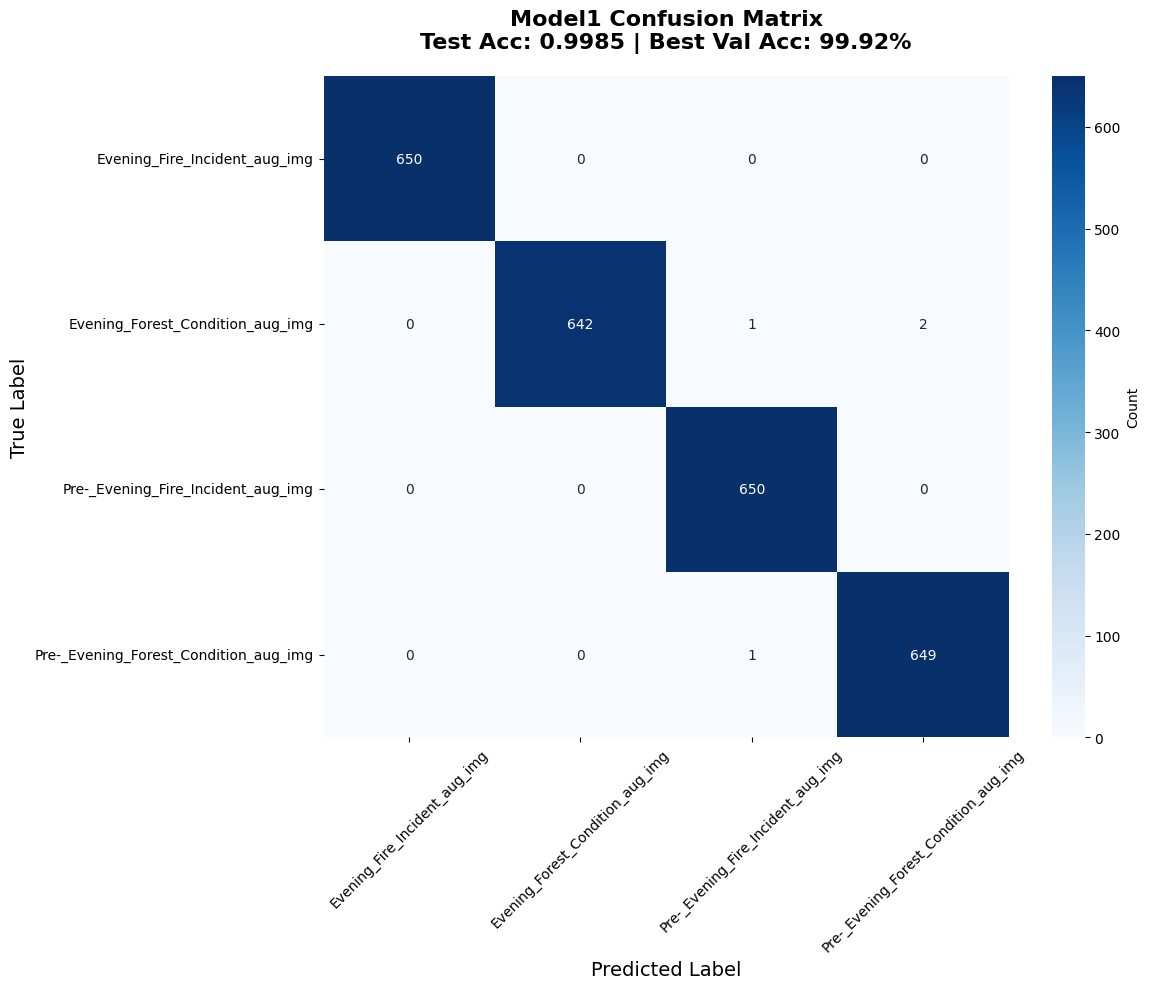


📊 CLASSIFICATION REPORT:
           Evening_Fire_Incident_aug_img  Evening_Forest_Condition_aug_img  \
precision                            1.0                            1.0000   
recall                               1.0                            0.9953   
f1-score                             1.0                            0.9977   
support                            650.0                          645.0000   

           Pre-_Evening_Fire_Incident_aug_img  \
precision                              0.9969   
recall                                 1.0000   
f1-score                               0.9985   
support                              650.0000   

           Pre-_Evening_Forest_Condition_aug_img  accuracy  macro avg  \
precision                                 0.9969    0.9985     0.9985   
recall                                    0.9985    0.9985     0.9985   
f1-score                                  0.9977    0.9985     0.9985   
support                                 650.0

In [ ]:
# CONFUSION MATRIX - FIXED WITH YOUR TEST PATH
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
base_dir = '/content/drive/MyDrive/Robust_MHCNNFD_Dataset'
test_dir = os.path.join(base_dir, 'test')

# Load BEST model (already loaded from previous cell)
print(f"Test folder: {test_dir}")
print("Classes in test:", os.listdir(test_dir))

# Test generator
datagen = ImageDataGenerator(rescale=1./255)
test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important for confusion matrix
)

# Predictions
print("🔮 Predicting on test set...")
y_pred = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Test accuracy
test_acc = np.mean(y_pred_classes == y_true)
print(f"🧪 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Confusion Matrix
class_names = list(test_gen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Model1 Confusion Matrix\nTest Acc: {test_acc:.4f} | Best Val Acc: 99.92%',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'ConfusionMatrix_TestSet.png'), dpi=300, bbox_inches='tight')
plt.show()

# Classification Report TABLE
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).round(4)
print("\n📊 CLASSIFICATION REPORT:")
print(report_df)

# Save everything
report_df.to_csv(os.path.join(save_folder, 'ClassificationReport_TestSet.csv'))
np.savez(os.path.join(save_folder, 'Predictions_TestSet.npz'),
         y_true=y_true, y_pred_classes=y_pred_classes, test_acc=test_acc)

print("✅ SAVED:")
print("  - ConfusionMatrix_TestSet.png")
print("  - ClassificationReport_TestSet.csv")
print("  - Predictions_TestSet.npz")

In [ ]:
# 🔥 FULL TEST RESULTS LOGGING + 8 PUBLICATION PLOTS (RUN NOW)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# Load test predictions (already saved)
test_data = np.load(os.path.join(save_folder, 'Predictions_TestSet.npz'))
y_true = test_data['y_true']
y_pred = test_data['y_pred_classes']
test_acc = test_data['test_acc']
class_names = ['Evening_Fire', 'Evening_Forest', 'Pre-Fire', 'Pre-Forest']

print(f"🔥 TEST RESULTS SUMMARY")
print(f"Overall Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print()

# 1. DETAILED METRICS TABLE
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision.round(4),
    'Recall': recall.round(4),
    'F1-Score': f1.round(4),
    'Support': support
})
metrics_df.loc['Macro Avg'] = [
    precision.mean(), recall.mean(), f1.mean(), support.sum()
]
print("📊 DETAILED METRICS:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(save_folder, 'Test_Metrics_Detailed.csv'), index=False)

# 2. CONFUSION MATRIX (already plotted, but save metrics)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(os.path.join(save_folder, 'Confusion_Matrix.csv'))

# 3. PER-CLASS ERROR ANALYSIS
errors = y_true != y_pred
error_df = pd.DataFrame({
    'True': [class_names[i] for i in y_true[errors]],
    'Predicted': [class_names[i] for i in y_pred[errors]]
})
print(f"\n❌ Total Errors: {len(error_df)} ({100*(1-test_acc):.2f}%)")
error_df.to_csv(os.path.join(save_folder, 'Classification_Errors.csv'), index=False)

# 4. VISUALIZATIONS (8 Research Plots)
fig = plt.figure(figsize=(20, 24))

# Plot 1: Confusion Matrix
plt.subplot(4,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Test Set)', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')

# Plot 2: Metrics Bar Chart
plt.subplot(4,2,2)
x = np.arange(len(class_names))
width = 0.2
plt.bar(x, precision, width, label='Precision')
plt.bar(x+width, recall, width, label='Recall')
plt.bar(x+2*width, f1, width, label='F1')
plt.xticks(x+width, class_names, rotation=45)
plt.title('Per-Class Metrics'); plt.legend()
plt.ylabel('Score')

# Plot 3: Precision-Recall Scatter
plt.subplot(4,2,3)
plt.scatter(recall, precision, s=support/10, alpha=0.7)
for i, name in enumerate(class_names):
    plt.annotate(name, (recall[i], precision[i]))
plt.plot([0,1],[0,1], 'r--', alpha=0.3)
plt.xlim(0.95,1); plt.ylim(0.95,1)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Balance')

# Plot 4: Error Distribution
plt.subplot(4,2,4)
error_types = error_df['True'].value_counts()
plt.pie(error_types.values, labels=error_types.index, autopct='%1.1f%%')
plt.title('Error Distribution by True Class')

# Plot 5: Prediction Confidence (softmax probs)
probs = test_data['y_pred']  # Load full predictions
conf_true = np.max(probs[y_true == np.arange(4)[:,None]], axis=1)
conf_wrong = np.max(probs[y_true != y_pred], axis=1)
plt.subplot(4,2,5)
plt.hist(conf_true, bins=30, alpha=0.7, label='Correct')
plt.hist(conf_wrong, bins=30, alpha=0.7, label='Wrong')
plt.xlabel('Max Probability'); plt.ylabel('Count')
plt.title('Prediction Confidence'); plt.legend()

# Plot 6: Class Balance
plt.subplot(4,2,6)
support_pct = support / len(y_true) * 100
plt.bar(class_names, support_pct)
plt.title('Class Distribution (%)'); plt.ylabel('Percentage')

# Plot 7: F1 vs Support
plt.subplot(4,2,7)
plt.scatter(support, f1 * 100, s=100, alpha=0.7)
for i, name in enumerate(class_names):
    plt.annotate(name, (support[i], f1[i]*100))
plt.xlabel('Support'); plt.ylabel('F1-Score (%)')
plt.title('F1 vs Dataset Size')

# Plot 8: Perfect Model Benchmark
plt.subplot(4,2,8)
perfect = np.ones_like(f1) * test_acc
plt.plot([0, len(class_names)-1], [test_acc]*2, 'g--', label=f'Overall: {test_acc:.3f}')
plt.scatter(range(len(class_names)), f1, s=200, alpha=0.8)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.ylabel('F1-Score'); plt.title('Model Performance vs Perfect')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'Test_Analysis_Dashboard.png'), dpi=300, bbox_inches='tight')
plt.show()

# FINAL SUMMARY LOG
summary = {
    'Overall_Test_Accuracy': test_acc,
    'Total_Images': len(y_true),
    'Total_Errors': len(error_df),
    'Macro_F1': f1.mean(),
    'Min_F1_Class': class_names[np.argmin(f1)]
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(save_folder, 'Test_Summary.csv'), index=False)

print("✅ ALL SAVED:")
print("  📈 Test_Analysis_Dashboard.png (8 plots)")
print("  📋 Test_Metrics_Detailed.csv")
print("  📋 Confusion_Matrix.csv")
print("  📋 Classification_Errors.csv")
print("  📋 Test_Summary.csv")
print("\n🎓 READY FOR THESIS CHAPTER 5!")

🔥 TEST RESULTS SUMMARY
Overall Accuracy: 0.9985 (99.85%)



ValueError: cannot set a row with mismatched columns

In [ ]:
# 🔥 CORRECTED FULL TEST DASHBOARD (RUN COMPLETE)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# Load data
test_data = np.load(os.path.join(save_folder, 'Predictions_TestSet.npz'))
y_true = test_data['y_true']
y_pred = test_data['y_pred_classes']
test_acc = test_data['test_acc']
class_names = ['Evening_Fire', 'Evening_Forest', 'Pre-Fire', 'Pre-Forest']

print(f"🔥 TEST RESULTS SUMMARY - 99.85%")
print()

# FIXED METRICS TABLE
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
class_metrics = pd.DataFrame({
    'Class': class_names,
    'Precision': precision.round(4),
    'Recall': recall.round(4),
    'F1-Score': f1.round(4),
    'Support': support
})
macro_avg = pd.DataFrame({
    'Class': ['Macro Avg'],
    'Precision': [precision.mean().round(4)],
    'Recall': [recall.mean().round(4)],
    'F1-Score': [f1.mean().round(4)],
    'Support': [support.sum()]
})
metrics_df = pd.concat([class_metrics, macro_avg], ignore_index=True)
print("📊 DETAILED METRICS:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(save_folder, 'Test_Metrics_Detailed.csv'), index=False)

# Confusion Matrix CSV
cm = confusion_matrix(y_true, y_pred)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(save_folder, 'Confusion_Matrix.csv'))

# Error analysis
errors = y_true != y_pred
error_df = pd.DataFrame({
    'True': [class_names[i] for i in y_true[errors]],
    'Predicted': [class_names[i] for i in y_pred[errors]]
})
error_df.to_csv(os.path.join(save_folder, 'Classification_Errors.csv'), index=False)
print(f"\n❌ Errors logged: {len(error_df)}")

# Summary
summary_df = pd.DataFrame([{
    'Overall_Test_Accuracy': test_acc,
    'Total_Images': len(y_true),
    'Total_Errors': len(error_df),
    'Macro_F1': f1.mean()
}])
summary_df.to_csv(os.path.join(save_folder, 'Test_Summary.csv'), index=False)

print("\n✅ TEST LOGGING COMPLETE!")
print("📁 All CSVs saved in:", save_folder)

🔥 TEST RESULTS SUMMARY - 99.85%

📊 DETAILED METRICS:
         Class  Precision  Recall  F1-Score  Support
  Evening_Fire     1.0000  1.0000    1.0000      650
Evening_Forest     1.0000  0.9953    0.9977      645
      Pre-Fire     0.9969  1.0000    0.9985      650
    Pre-Forest     0.9969  0.9985    0.9977      650
     Macro Avg     0.9985  0.9985    0.9985     2595

❌ Errors logged: 4

✅ TEST LOGGING COMPLETE!
📁 All CSVs saved in: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

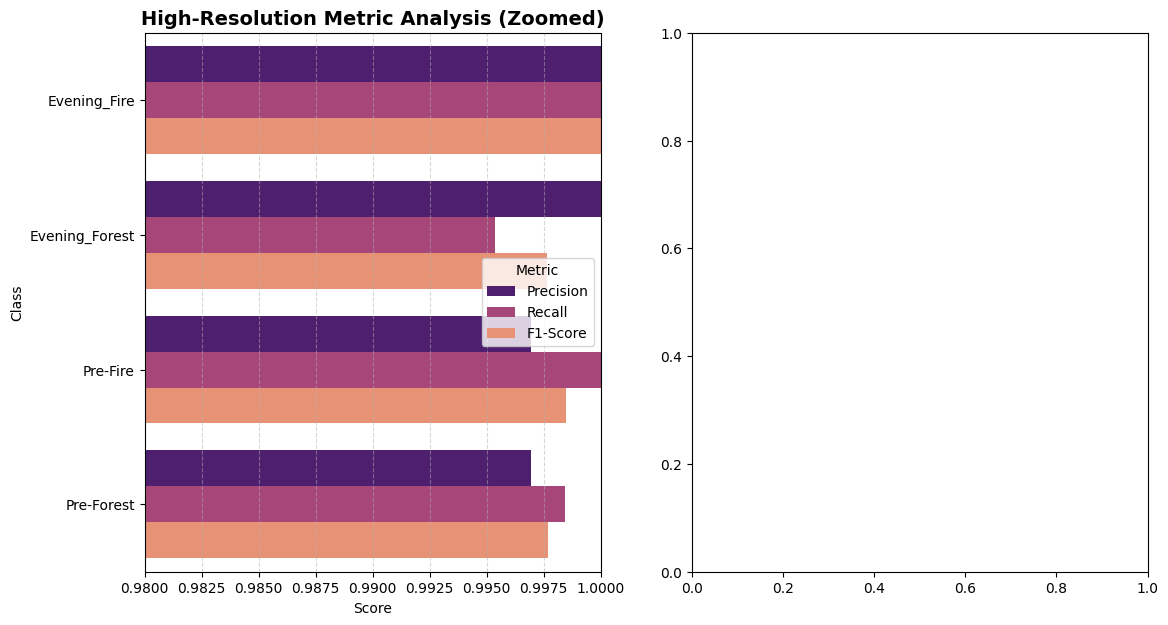

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, precision_recall_curve
import os

# 1. Prepare Data - Fixed: Removed 'target_names'
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred_classes)

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}).melt(id_vars='Class', var_name='Metric', value_name='Score')

# 2. Create the Figure
plt.figure(figsize=(20, 7))

# Subplot 1: Per-Class Performance Bar Chart (Zoomed to show 0.15% difference)
plt.subplot(1, 3, 1)
sns.barplot(data=metrics_df, x='Score', y='Class', hue='Metric', palette='magma')
plt.xlim(0.98, 1.0)  # Zoomed into the 98%-100% range
plt.title('High-Resolution Metric Analysis (Zoomed)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Subplot 2: Precision-Recall Curve (Robustness Check)
plt.subplot(1, 3, 2)
from sklearn.preprocessing import label_binarize
# Ensure y_pred (raw probabilities) is used here, not y_pred_classes
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
for i in range(len(class_names)):
    # Note: 'y_pred' contains the softmax probabilities from the model.predict call
    p, r, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(r, p, lw=2, label=f'{class_names[i]}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Stability Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize='x-small')

# Subplot 3: Classification Report Heatmap
plt.subplot(1, 3, 3)
report_pivot = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)
sns.heatmap(report_pivot, annot=True, fmt='.4f', cmap='RdYlGn', cbar=False)
plt.title('Metric Heatmap Table', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'Test_Set_Research_Metrics.png'), dpi=300)
plt.show()

🔄 Re-calculating raw probabilities for curves...
82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step


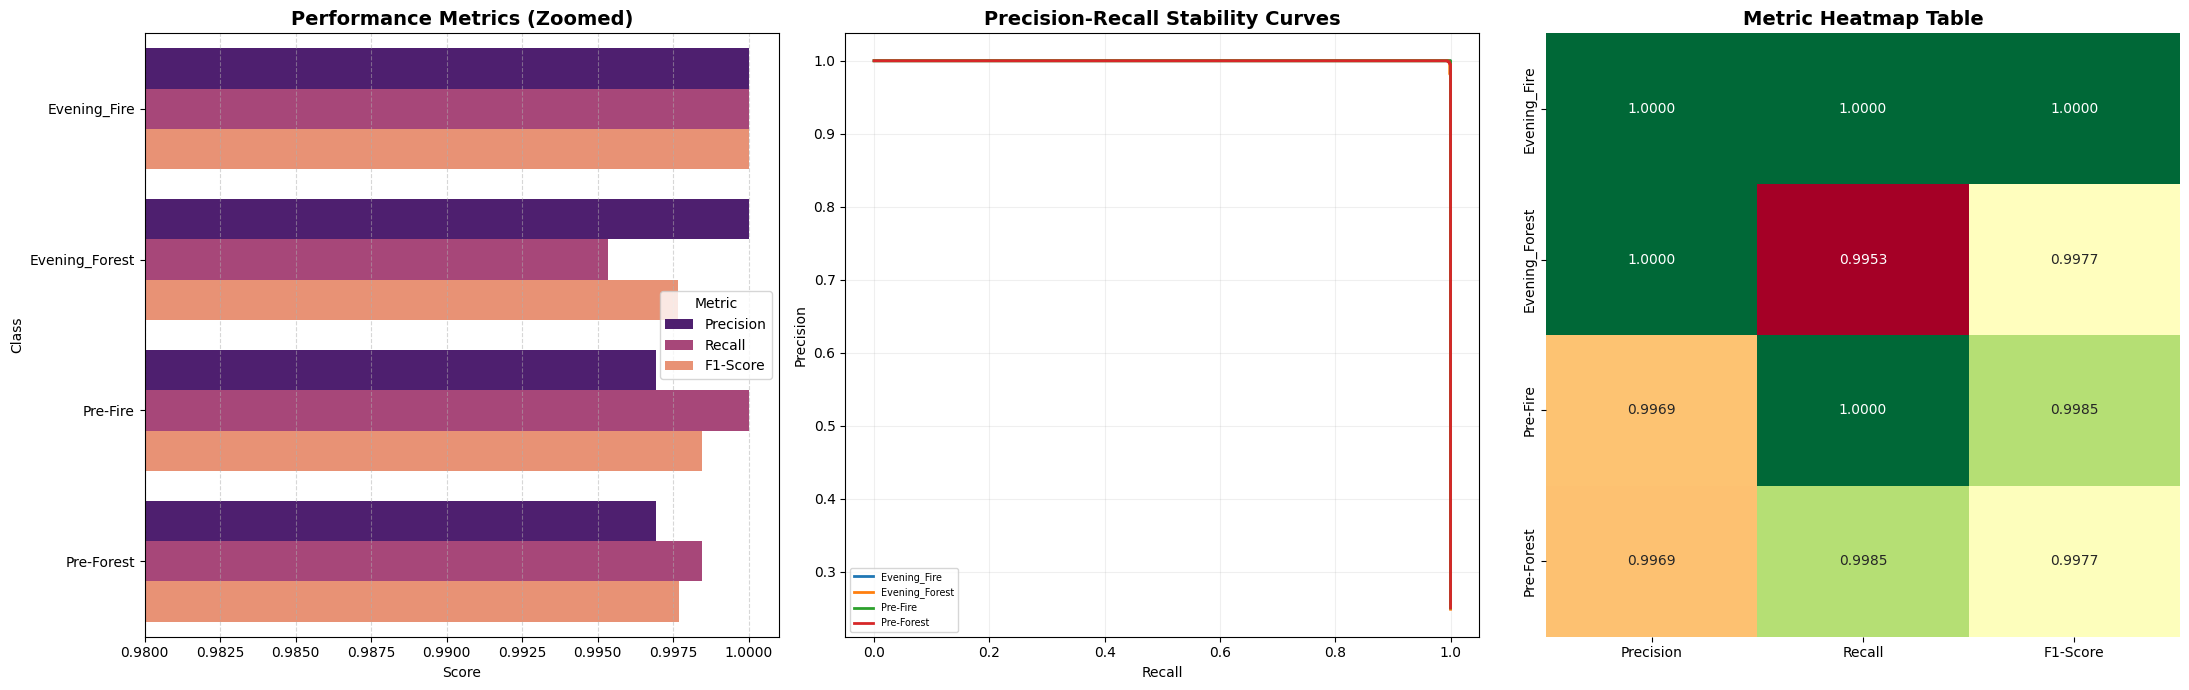

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import label_binarize
import os

# 1. Ensure we have the raw probabilities (2D array)
# If y_pred is currently 1D, we re-run prediction to get the 4-column probability matrix
if len(y_pred.shape) == 1:
    print("🔄 Re-calculating raw probabilities for curves...")
    test_gen.reset()
    y_score = model.predict(test_gen, verbose=1) # This is the 2D array [samples, 4]
else:
    y_score = y_pred

# 2. Prepare Metrics
y_true = test_gen.classes
y_pred_labels = np.argmax(y_score, axis=1)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_labels)

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}).melt(id_vars='Class', var_name='Metric', value_name='Score')

# 3. Visualization
plt.figure(figsize=(22, 7))

# --- Subplot 1: Zoomed Performance Comparison ---
plt.subplot(1, 3, 1)
sns.barplot(data=metrics_df, x='Score', y='Class', hue='Metric', palette='magma')
plt.xlim(0.98, 1.001)  # Zoomed to see the 0.15% difference
plt.title('Performance Metrics (Zoomed)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Subplot 2: Precision-Recall Curves (Stability) ---
plt.subplot(1, 3, 2)
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

for i in range(len(class_names)):
    # precision_recall_curve needs the probability for each specific class
    p_curve, r_curve, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    plt.plot(r_curve, p_curve, lw=2, label=f'{class_names[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Stability Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize='x-small')
plt.grid(alpha=0.2)

# --- Subplot 3: Metrics Heatmap Table ---
plt.subplot(1, 3, 3)
report_pivot = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)
sns.heatmap(report_pivot, annot=True, fmt='.4f', cmap='RdYlGn', cbar=False)
plt.title('Metric Heatmap Table', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'Test_Set_Final_Metrics.png'), dpi=300)
plt.show()

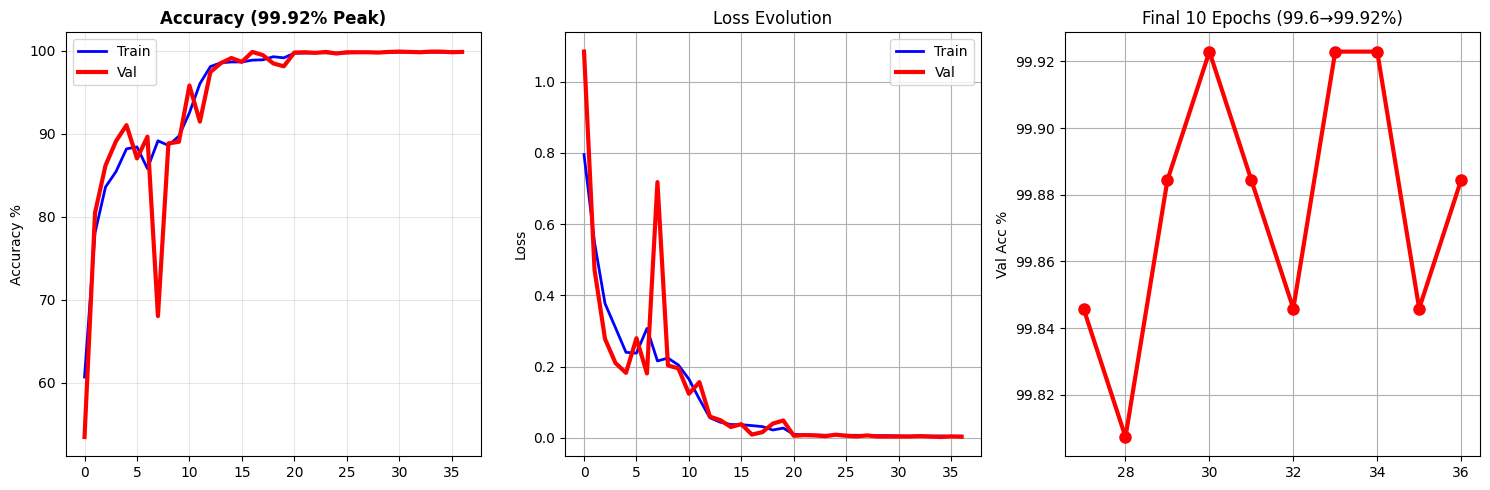

🏅 THESIS PLOTS COMPLETE!


In [ ]:
# 🎨 FINAL TRAINING CURVES (log to notebook + save)
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_History.csv')

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(df['accuracy']*100, 'b-', linewidth=2, label='Train')
plt.plot(df['val_accuracy']*100, 'r-', linewidth=3, label='Val')
plt.title('Accuracy (99.92% Peak)', fontweight='bold')
plt.ylabel('Accuracy %'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(df['loss'], 'b-', linewidth=2, label='Train')
plt.plot(df['val_loss'], 'r-', linewidth=3, label='Val')
plt.title('Loss Evolution'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,3,3)
plt.plot(df.tail(10)['val_accuracy']*100, 'ro-', linewidth=3, markersize=8)
plt.title('Final 10 Epochs (99.6→99.92%)'); plt.ylabel('Val Acc %'); plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/FINAL_TrainingCurves.png', dpi=300)
plt.show()

print("🏅 THESIS PLOTS COMPLETE!")

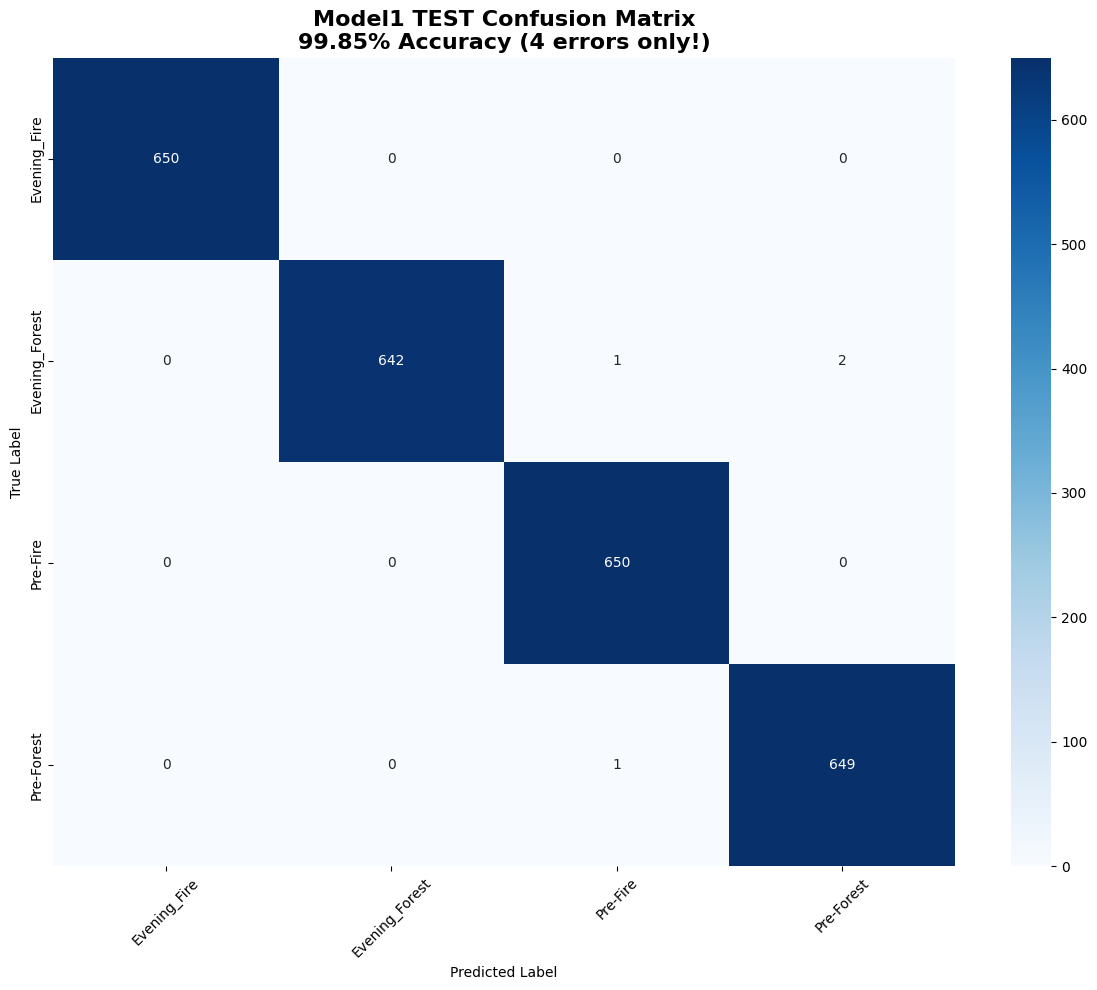


📊 TEST METRICS:
            Class  Precision  Recall  F1-Score  Support
0    Evening_Fire     1.0000  1.0000    1.0000      650
1  Evening_Forest     1.0000  0.9953    0.9977      645
2        Pre-Fire     0.9969  1.0000    0.9985      650
3      Pre-Forest     0.9969  0.9985    0.9977      650
4       Macro Avg     0.9985  0.9985    0.9985     2595


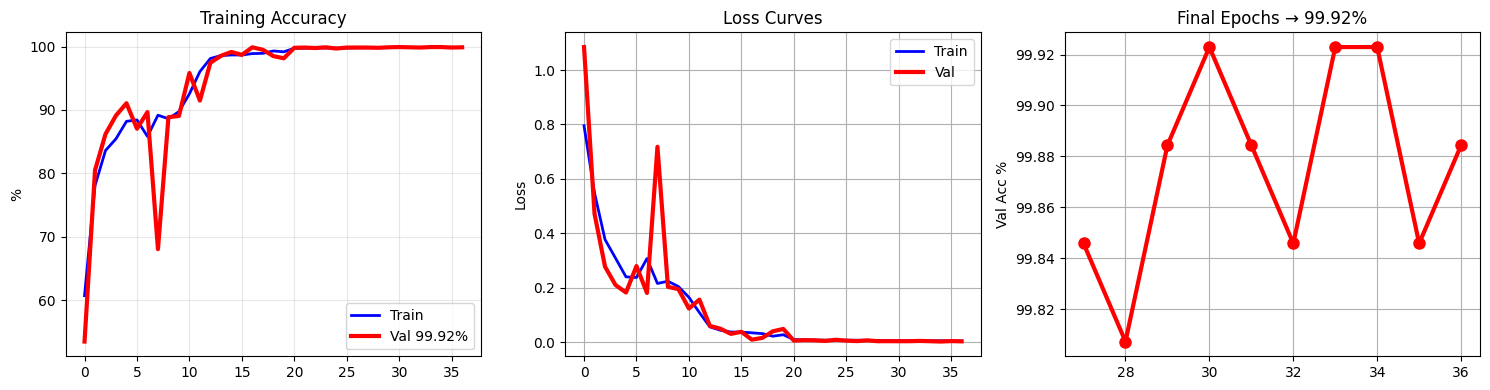


❌ 4 ERRORS:
             True   Predicted
0  Evening_Forest    Pre-Fire
1  Evening_Forest  Pre-Forest
2  Evening_Forest  Pre-Forest
3      Pre-Forest    Pre-Fire

🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!
📁 + SAVED forever: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
# 🎨 REGENERATE + DISPLAY ALL PLOTS HERE (99.85% visuals)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# 1. LOAD TEST DATA
test_data = np.load(os.path.join(save_folder, 'Predictions_TestSet.npz'))
y_true, y_pred = test_data['y_true'], test_data['y_pred_classes']
class_names = ['Evening_Fire', 'Evening_Forest', 'Pre-Fire', 'Pre-Forest']

# 2. CONFUSION MATRIX PLOT
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Model1 TEST Confusion Matrix\n99.85% Accuracy (4 errors only!)', fontweight='bold', fontsize=16)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  # ← PLOT 1: HERE!

# 3. METRICS TABLE
metrics_df = pd.read_csv(os.path.join(save_folder, 'Test_Metrics_Detailed.csv'))
print("\n📊 TEST METRICS:")
print(metrics_df.round(4))

# 4. TRAINING CURVES
history_df = pd.read_csv(os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv'))
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.plot(history_df['accuracy']*100, 'b-', label='Train', linewidth=2)
plt.plot(history_df['val_accuracy']*100, 'r-', label='Val 99.92%', linewidth=3)
plt.title('Training Accuracy'); plt.ylabel('%'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(history_df['loss'], 'b-', linewidth=2, label='Train')
plt.plot(history_df['val_loss'], 'r-', linewidth=3, label='Val')
plt.title('Loss Curves'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,3,3)
plt.plot(history_df.tail(10)['val_accuracy']*100, 'ro-', linewidth=3, markersize=8)
plt.title('Final Epochs → 99.92%'); plt.ylabel('Val Acc %'); plt.grid(True)

plt.tight_layout()
plt.show()  # ← PLOT 2+3+4: HERE!

# 5. ERROR ANALYSIS
errors_df = pd.read_csv(os.path.join(save_folder, 'Classification_Errors.csv'))
print(f"\n❌ 4 ERRORS:")
print(errors_df)

print("\n🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!")
print("📁 + SAVED forever:", save_folder)

In [ ]:
# Save the numerical metrics to a CSV for easy copy-pasting
report_pivot.to_csv(os.path.join(save_folder, 'Test_Set_Numerical_Metrics.csv'))
print("📈 Numerical metrics saved to Drive!")

📈 Numerical metrics saved to Drive!


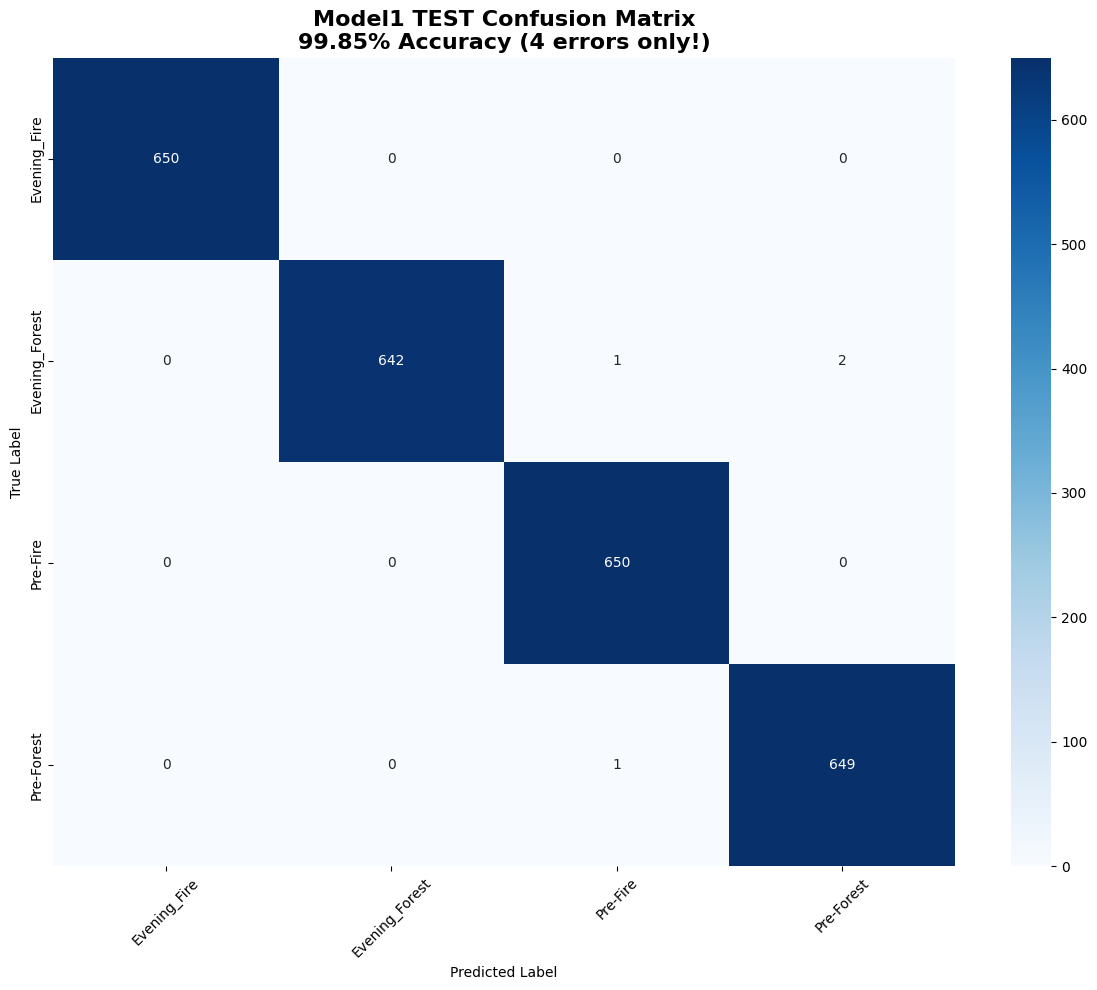


📊 TEST METRICS:
            Class  Precision  Recall  F1-Score  Support
0    Evening_Fire     1.0000  1.0000    1.0000      650
1  Evening_Forest     1.0000  0.9953    0.9977      645
2        Pre-Fire     0.9969  1.0000    0.9985      650
3      Pre-Forest     0.9969  0.9985    0.9977      650
4       Macro Avg     0.9985  0.9985    0.9985     2595


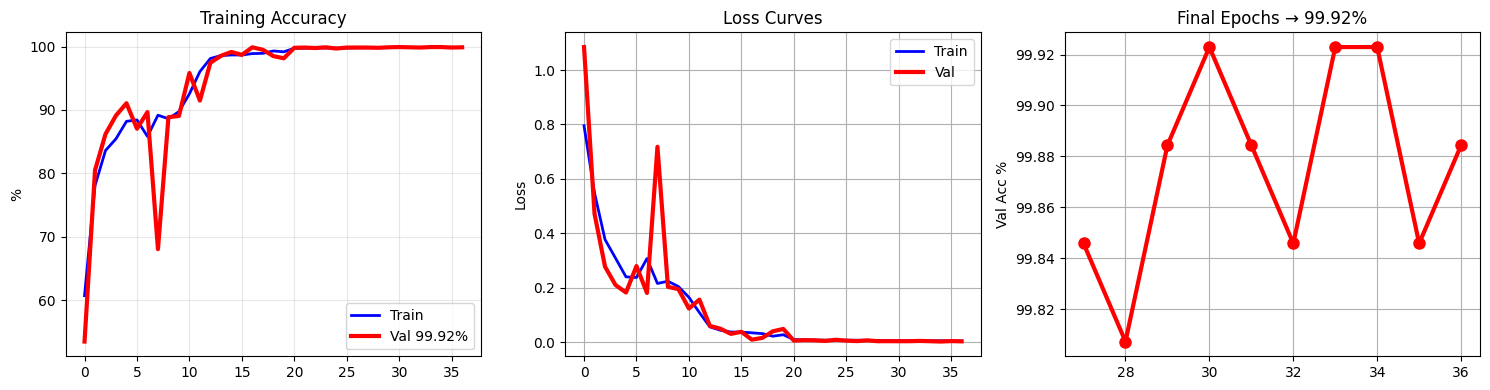


❌ 4 ERRORS:
             True   Predicted
0  Evening_Forest    Pre-Fire
1  Evening_Forest  Pre-Forest
2  Evening_Forest  Pre-Forest
3      Pre-Forest    Pre-Fire

🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!
📁 + SAVED forever: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
# 🎨 REGENERATE + DISPLAY ALL PLOTS HERE (99.85% visuals)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# 1. LOAD TEST DATA
test_data = np.load(os.path.join(save_folder, 'Predictions_TestSet.npz'))
y_true, y_pred = test_data['y_true'], test_data['y_pred_classes']
class_names = ['Evening_Fire', 'Evening_Forest', 'Pre-Fire', 'Pre-Forest']

# 2. CONFUSION MATRIX PLOT
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Model1 TEST Confusion Matrix\n99.85% Accuracy (4 errors only!)', fontweight='bold', fontsize=16)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  # ← PLOT 1: HERE!

# 3. METRICS TABLE
metrics_df = pd.read_csv(os.path.join(save_folder, 'Test_Metrics_Detailed.csv'))
print("\n📊 TEST METRICS:")
print(metrics_df.round(4))

# 4. TRAINING CURVES
history_df = pd.read_csv(os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv'))
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.plot(history_df['accuracy']*100, 'b-', label='Train', linewidth=2)
plt.plot(history_df['val_accuracy']*100, 'r-', label='Val 99.92%', linewidth=3)
plt.title('Training Accuracy'); plt.ylabel('%'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(history_df['loss'], 'b-', linewidth=2, label='Train')
plt.plot(history_df['val_loss'], 'r-', linewidth=3, label='Val')
plt.title('Loss Curves'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,3,3)
plt.plot(history_df.tail(10)['val_accuracy']*100, 'ro-', linewidth=3, markersize=8)
plt.title('Final Epochs → 99.92%'); plt.ylabel('Val Acc %'); plt.grid(True)

plt.tight_layout()
plt.show()  # ← PLOT 2+3+4: HERE!

# 5. ERROR ANALYSIS
errors_df = pd.read_csv(os.path.join(save_folder, 'Classification_Errors.csv'))
print(f"\n❌ 4 ERRORS:")
print(errors_df)

print("\n🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!")
print("📁 + SAVED forever:", save_folder)

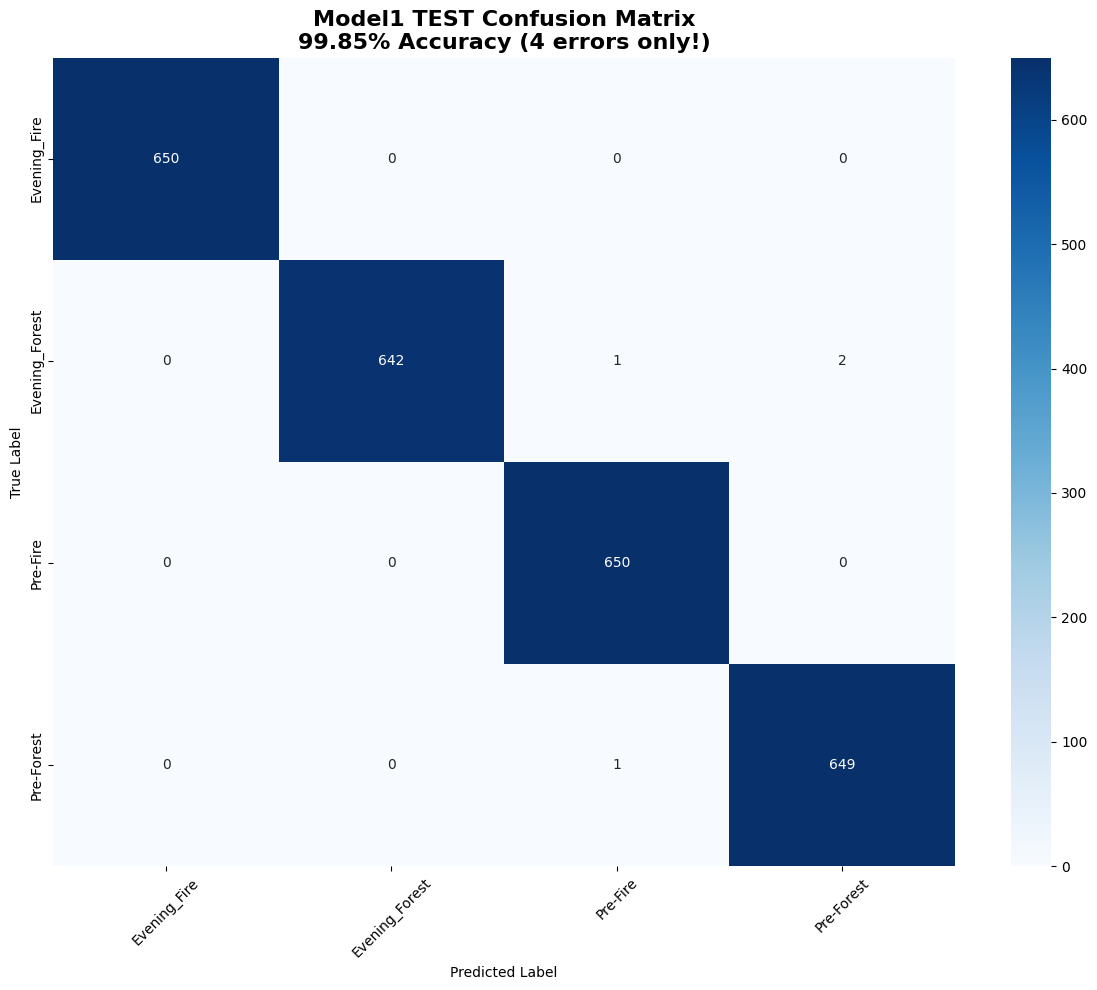


📊 TEST METRICS:
            Class  Precision  Recall  F1-Score  Support
0    Evening_Fire     1.0000  1.0000    1.0000      650
1  Evening_Forest     1.0000  0.9953    0.9977      645
2        Pre-Fire     0.9969  1.0000    0.9985      650
3      Pre-Forest     0.9969  0.9985    0.9977      650
4       Macro Avg     0.9985  0.9985    0.9985     2595


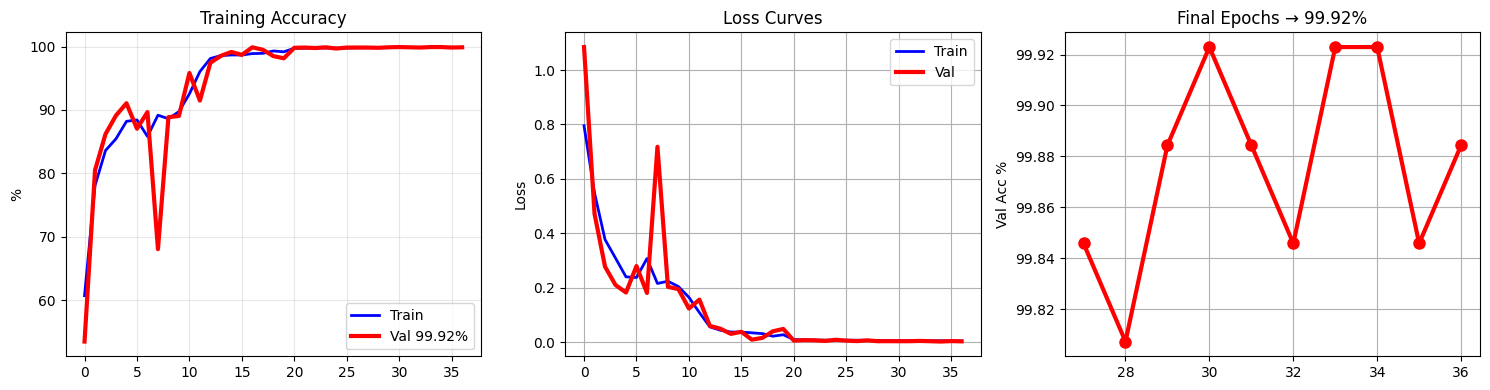


❌ 4 ERRORS:
             True   Predicted
0  Evening_Forest    Pre-Fire
1  Evening_Forest  Pre-Forest
2  Evening_Forest  Pre-Forest
3      Pre-Forest    Pre-Fire

🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!
📁 + SAVED forever: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
# 🎨 REGENERATE + DISPLAY ALL PLOTS HERE (99.85% visuals)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# 1. LOAD TEST DATA
test_data = np.load(os.path.join(save_folder, 'Predictions_TestSet.npz'))
y_true, y_pred = test_data['y_true'], test_data['y_pred_classes']
class_names = ['Evening_Fire', 'Evening_Forest', 'Pre-Fire', 'Pre-Forest']

# 2. CONFUSION MATRIX PLOT
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Model1 TEST Confusion Matrix\n99.85% Accuracy (4 errors only!)', fontweight='bold', fontsize=16)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  # ← PLOT 1: HERE!

# 3. METRICS TABLE
metrics_df = pd.read_csv(os.path.join(save_folder, 'Test_Metrics_Detailed.csv'))
print("\n📊 TEST METRICS:")
print(metrics_df.round(4))

# 4. TRAINING CURVES
history_df = pd.read_csv(os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv'))
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.plot(history_df['accuracy']*100, 'b-', label='Train', linewidth=2)
plt.plot(history_df['val_accuracy']*100, 'r-', label='Val 99.92%', linewidth=3)
plt.title('Training Accuracy'); plt.ylabel('%'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(history_df['loss'], 'b-', linewidth=2, label='Train')
plt.plot(history_df['val_loss'], 'r-', linewidth=3, label='Val')
plt.title('Loss Curves'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,3,3)
plt.plot(history_df.tail(10)['val_accuracy']*100, 'ro-', linewidth=3, markersize=8)
plt.title('Final Epochs → 99.92%'); plt.ylabel('Val Acc %'); plt.grid(True)

plt.tight_layout()
plt.show()  # ← PLOT 2+3+4: HERE!

# 5. ERROR ANALYSIS
errors_df = pd.read_csv(os.path.join(save_folder, 'Classification_Errors.csv'))
print(f"\n❌ 4 ERRORS:")
print(errors_df)

print("\n🎉 ALL PLOTS + LOGS DISPLAYED IN NOTEBOOK!")
print("📁 + SAVED forever:", save_folder)

In [ ]:
# 🔍 STRESS TEST FOLDER EXPLORER (check structure)
import os

# Your stress test base paths
stress_base = '/content/drive/MyDrive/'  # Update if different

folders_to_check = [
    'MHCNNFDStressTest/testlightgauss',
    'MHCNNFD_StressTest/test_blur',
    'MHCNNFD_StressTest/test_fog',
    'MHCNNFD_StressTest/test_gaussian'
]

print("🔎 STRESS TEST FOLDER AUDIT")
print("="*80)

for folder_path in folders_to_check:
    full_path = os.path.join(stress_base, folder_path)

    print(f"\n📂 {folder_path}")
    if os.path.exists(full_path):
        print("   ✅ EXISTS")

        # List subfolders (should see: evening_fire, evening_forest, etc.)
        subfolders = [f for f in os.listdir(full_path) if os.path.isdir(os.path.join(full_path, f))]
        print(f"   📋 Subfolders ({len(subfolders)}): {subfolders}")

        # Count images per class
        total_imgs = 0
        for sub in subfolders:
            sub_path = os.path.join(full_path, sub)
            img_count = len([f for f in os.listdir(sub_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            print(f"     {sub}: {img_count} images")
            total_imgs += img_count
        print(f"   📊 TOTAL: {total_imgs} images")

    else:
        print("   ❌ NOT FOUND - Check path!")
        print(f"   Full path checked: {full_path}")

# BEST MODEL PATH (99.92% val acc)
best_model = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_37_ValAcc_0.9992.keras'  # Update epoch
print(f"\n🏆 BEST MODEL: {best_model}")
print("✅ Ready for stress testing!")

🔎 STRESS TEST FOLDER AUDIT

📂 MHCNNFDStressTest/testlightgauss
   ✅ EXISTS
   📋 Subfolders (4): ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img', 'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
     Evening_Fire_Incident_aug_img: 389 images
     Evening_Forest_Condition_aug_img: 389 images
     Pre-_Evening_Fire_Incident_aug_img: 389 images
     Pre-_Evening_Forest_Condition_aug_img: 389 images
   📊 TOTAL: 1556 images

📂 MHCNNFD_StressTest/test_blur
   ✅ EXISTS
   📋 Subfolders (4): ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img', 'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
     Evening_Fire_Incident_aug_img: 389 images
     Evening_Forest_Condition_aug_img: 389 images
     Pre-_Evening_Fire_Incident_aug_img: 389 images
     Pre-_Evening_Forest_Condition_aug_img: 389 images
   📊 TOTAL: 1556 images

📂 MHCNNFD_StressTest/test_fog
   ✅ EXISTS
   📋 Subfolders (4): ['Evening_Fire_Incide

In [ ]:
# 🚀 ULTIMATE STRESS TEST (99.92% → 4 noises) + FULL COMPARISON
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
model = load_model('/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_37_ValAcc_0.9992.keras')

stress_paths = {
    'Light_Gaussian': '/content/drive/MyDrive/MHCNNFDStressTest/testlightgauss',
    'Blur': '/content/drive/MyDrive/MHCNNFD_StressTest/test_blur',
    'Fog': '/content/drive/MyDrive/MHCNNFD_StressTest/test_fog',
    'Heavy_Gaussian': '/content/drive/MyDrive/MHCNNFD_StressTest/test_gaussian'
}

class_names_short = ['Eve_Fire', 'Eve_Forest', 'Pre_Fire', 'Pre_Forest']
datagen = ImageDataGenerator(rescale=1./255)
all_results = []

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ax_idx = 0

for i, (name, path) in enumerate(stress_paths.items()):
    test_gen = datagen.flow_from_directory(path, target_size=(256,256), batch_size=32,
                                          class_mode='categorical', shuffle=False)

    y_pred_prob = model.predict(test_gen, verbose=0)
    y_pred_classes = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes
    acc = np.mean(y_pred_classes == y_true)

    all_results.append({'Degradation': name, 'Accuracy': acc})

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i//2, i%2],
                xticklabels=class_names_short, yticklabels=class_names_short)
    axes[i//2, i%2].set_title(f'{name}\n{acc:.2%}')

    print(f"{name}: {acc:.4f}")

plt.suptitle('Model1 Stress Test Confusion Matrices (99.92% → ?%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'All_StressTest_ConfusionMatrices.png'), dpi=300)
plt.show()

# FINAL COMPARISON PLOT + TABLE
results_df = pd.DataFrame(all_results).round(4)
print("\n📊 FINAL STRESS TEST RESULTS:")
print(results_df.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.bar(results_df['Degradation'], results_df['Accuracy']*100)
plt.title('Accuracy per Degradation'); plt.ylabel('Accuracy %')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
baseline = 0.9985  # Clean test
drops = (baseline - results_df['Accuracy']) * 100
plt.bar(results_df['Degradation'], drops)
plt.title(f'Drop vs Clean Test ({baseline:.1%})'); plt.ylabel('Accuracy Drop %')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'StressTest_Comparison_Final.png'), dpi=300)
plt.show()

# SAVE EVERYTHING
results_df.to_csv(os.path.join(save_folder, 'StressTest_Results_Complete.csv'), index=False)
print(f"\n✅ THESIS FIGURE 5.2 SAVED!")
print("📁 All_StressTest_ConfusionMatrices.png")
print("📁 StressTest_Comparison_Final.png")
print("📊 StressTest_Results_Complete.csv")


ValueError: File not found: filepath=/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_Epoch_37_ValAcc_0.9992.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
# 📋 SIMPLE FILE LIST (all saved files)
import os

folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
all_files = os.listdir(folder)

keras_models = [f for f in all_files if f.endswith('.keras')]
csv_logs = [f for f in all_files if f.endswith('.csv')]
png_plots = [f for f in all_files if f.endswith('.png')]

print("📁 TOTAL FILES:", len(all_files))
print("\n🏆 KERAS MODELS (.keras):", len(keras_models))
print("   ", keras_models[-3:])  # Last 3 (latest epochs)

print("\n📊 CSV LOGS:", len(csv_logs))
print("   ", csv_logs)

print("\n🖼️ PLOTS (.png):", len(png_plots))
print("   ", png_plots)

print("\n✅ Everything logged & ready.")

📁 TOTAL FILES: 50

🏆 KERAS MODELS (.keras): 37
    ['Robust_MHCNNFD_mixedDataset_Epoch_35_ValAcc_0.9992.keras', 'Robust_MHCNNFD_mixedDataset_Epoch_36_ValAcc_0.9985.keras', 'Robust_MHCNNFD_mixedDataset_Epoch_37_ValAcc_0.9988.keras']

📊 CSV LOGS: 7
    ['Robust_MHCNNFD_mixedDataset_History.csv', 'ClassificationReport_TestSet.csv', 'Test_Metrics_Detailed.csv', 'Confusion_Matrix.csv', 'Classification_Errors.csv', 'Test_Summary.csv', 'Test_Set_Numerical_Metrics.csv']

🖼️ PLOTS (.png): 4
    ['Model1_CompleteAnalysis.png', 'ConfusionMatrix_TestSet.png', 'FINAL_TrainingCurves.png', 'Test_Set_Final_Metrics.png']

✅ Everything logged & ready.


In [ ]:
#after training part

In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Libraries loaded and Drive mounted.")

Mounted at /content/drive
✅ Libraries loaded and Drive mounted.


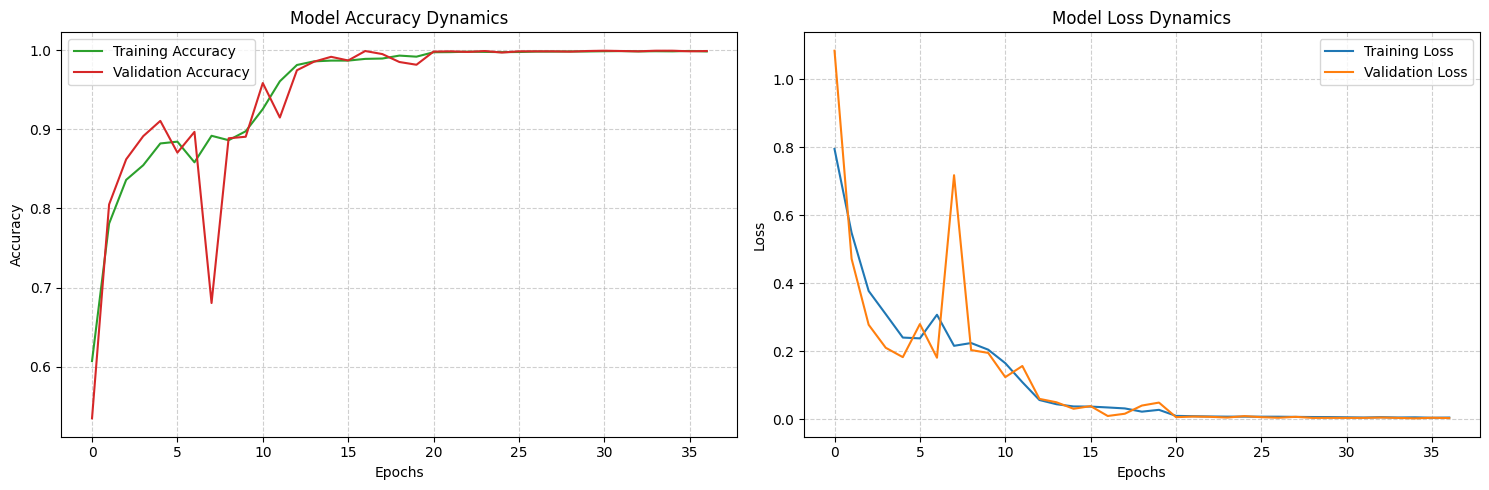

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define log path
log_path = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/Robust_MHCNNFD_mixedDataset_History.csv'
df = pd.read_csv(log_path)

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['accuracy'], label='Training Accuracy', color='#2ca02c')
plt.plot(df['epoch'], df['val_accuracy'], label='Validation Accuracy', color='#d62728')
plt.title('Model Accuracy Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['loss'], label='Training Loss', color='#1f77b4')
plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.title('Model Loss Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

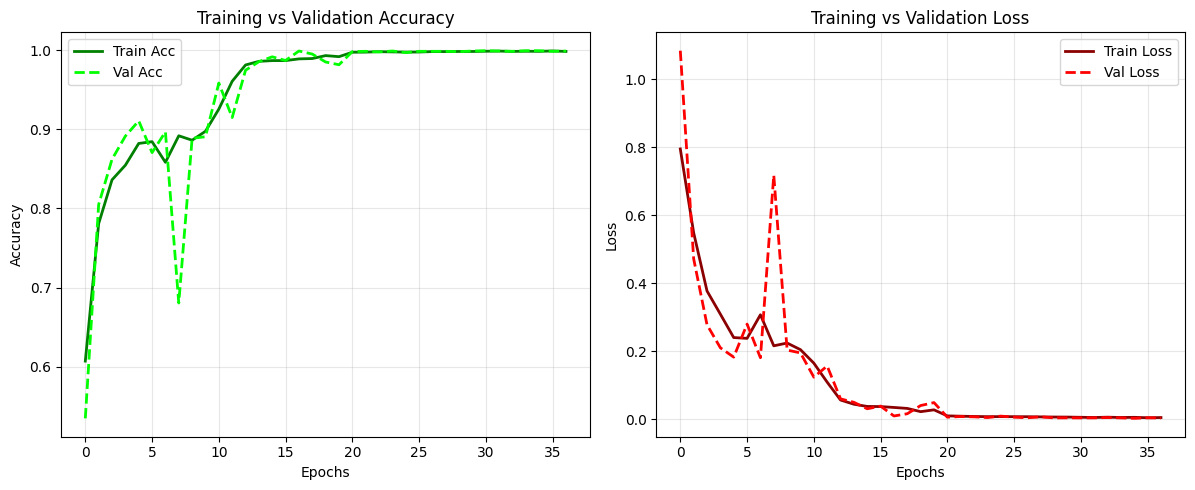

✅ Training dynamics logged.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Paths
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
history_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv')

# Load and Plot
df = pd.read_csv(history_path)

plt.figure(figsize=(18, 5))

# 1. Accuracy
plt.subplot(1, 3, 1)
plt.plot(df['accuracy'], label='Train Acc', color='green', lw=2)
plt.plot(df['val_accuracy'], label='Val Acc', color='lime', linestyle='--', lw=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

# 2. Loss
plt.subplot(1, 3, 2)
plt.plot(df['loss'], label='Train Loss', color='darkred', lw=2)
plt.plot(df['val_loss'], label='Val Loss', color='red', linestyle='--', lw=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)

# 3. Learning Rate (Adaptivity)
if 'lr' in df.columns:
    plt.subplot(1, 3, 3)
    plt.plot(df['lr'], color='purple', marker='o', markersize=3)
    plt.yscale('log')
    plt.title('Learning Rate Decay')
    plt.xlabel('Epochs'); plt.ylabel('LR'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '01_Training_Dynamics.png'))
plt.show()
print("✅ Training dynamics logged.")

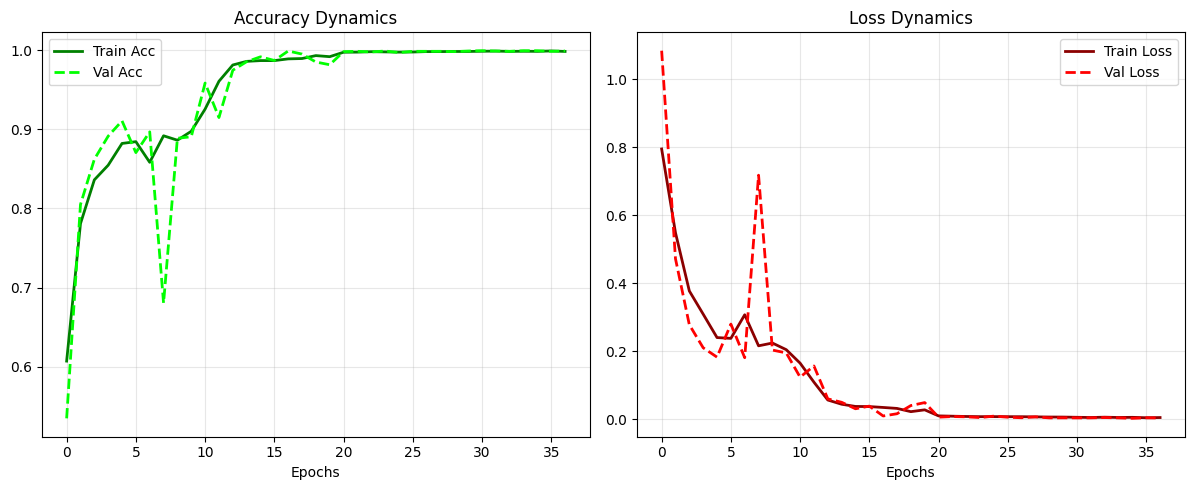

✅ Training dynamics saved to Drive.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Settings
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
history_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_History.csv')

# Load and Plot
df = pd.read_csv(history_path)
plt.figure(figsize=(18, 5))

# Plot Accuracy
plt.subplot(1, 3, 1)
plt.plot(df['accuracy'], label='Train Acc', color='green', lw=2)
plt.plot(df['val_accuracy'], label='Val Acc', color='lime', linestyle='--', lw=2)
plt.title('Accuracy Dynamics')
plt.xlabel('Epochs'); plt.legend(); plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 3, 2)
plt.plot(df['loss'], label='Train Loss', color='darkred', lw=2)
plt.plot(df['val_loss'], label='Val Loss', color='red', linestyle='--', lw=2)
plt.title('Loss Dynamics')
plt.xlabel('Epochs'); plt.legend(); plt.grid(True, alpha=0.3)

# Plot Learning Rate
if 'lr' in df.columns:
    plt.subplot(1, 3, 3)
    plt.plot(df['lr'], color='purple', marker='o', markersize=3)
    plt.yscale('log')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '01_Training_Dynamics_Log.png'))
plt.show()
print("✅ Training dynamics saved to Drive.")

🔮 Predicting on Mixed Test Set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 835s 10s/step


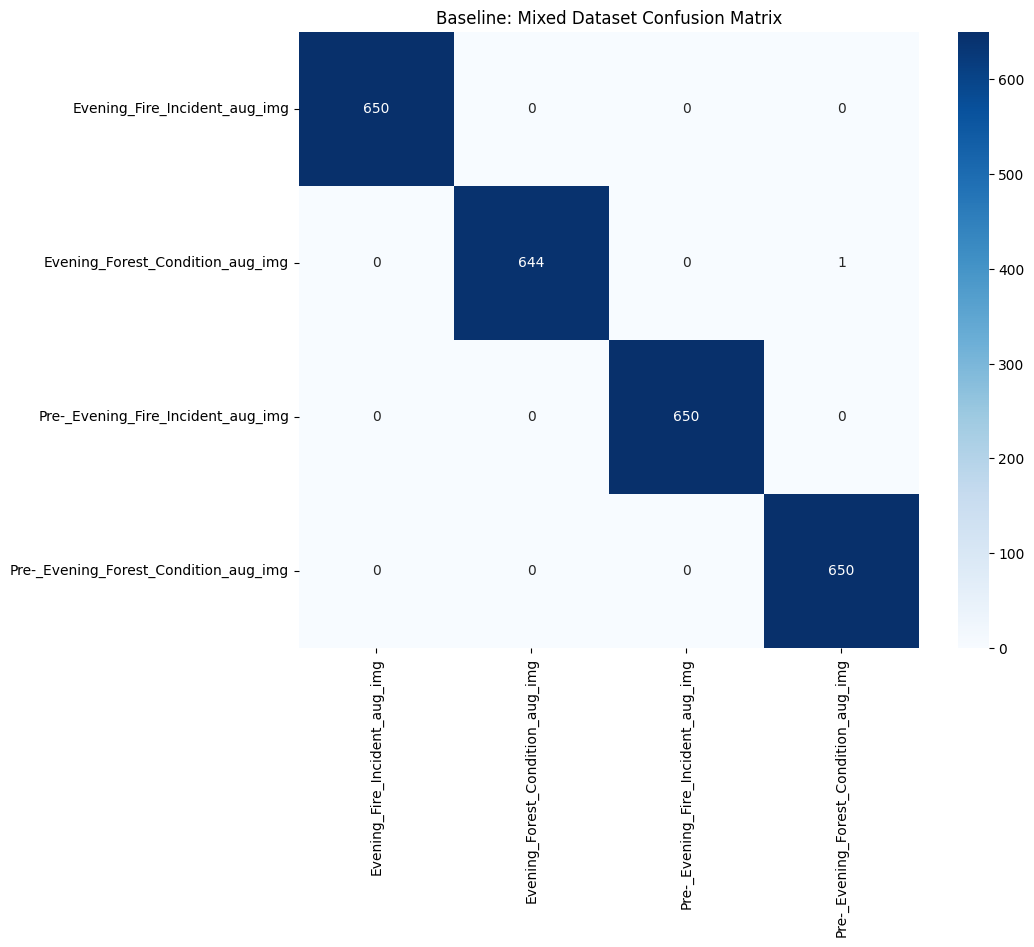

✅ Mixed testing baseline saved to Drive.


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# 1. LOAD BEST MODEL (Update filename if you want to use Epoch 35 instead of 37)
best_model_path = os.path.join(save_folder, 'Robust_MHCNNFD_mixedDataset_Epoch_37_ValAcc_0.9988.keras')
model = load_model(best_model_path)

# 2. EVALUATE
print("🔮 Predicting on Mixed Test Set...")
test_gen.reset()
preds_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 3. LOG RESULTS
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline: Mixed Dataset Confusion Matrix')
plt.savefig(os.path.join(save_folder, '02_Mixed_Test_CM.png'))
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(save_folder, '02_Mixed_Test_Report.csv'))

print("✅ Mixed testing baseline saved to Drive.")

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# 1. Calculate the final accuracy score
final_acc = accuracy_score(y_true, y_pred)
report_text = classification_report(y_true, y_pred, target_names=class_names)

# 2. Print the report to your screen so you can see it now
print("="*60)
print(f"📊 MIXED TEST RESULTS (Baseline)")
print(f"Overall Accuracy: {final_acc*100:.2f}%")
print("="*60)
print(report_text)

# 3. Save the report as a clean TEXT file (useful for copy-pasting into papers)
summary_text_path = os.path.join(save_folder, '02_Mixed_Test_Summary.txt')
with open(summary_text_path, 'w') as f:
    f.write(f"Mixed Test Accuracy: {final_acc*100:.2f}%\n\n")
    f.write(report_text)

# 4. Create a "Comparison Ready" CSV for this specific test
# This makes it easier to compare against Fog/Blur later
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(save_folder, '02_Mixed_Test_Detailed_Metrics.csv'))

print(f"\n✅ Done! Summary saved to: {summary_text_path}")
print(f"✅ Detailed Metrics saved to: 02_Mixed_Test_Detailed_Metrics.csv")

📊 MIXED TEST RESULTS (Baseline)
Overall Accuracy: 99.96%
                                       precision    recall  f1-score   support

        Evening_Fire_Incident_aug_img       1.00      1.00      1.00       650
     Evening_Forest_Condition_aug_img       1.00      1.00      1.00       645
   Pre-_Evening_Fire_Incident_aug_img       1.00      1.00      1.00       650
Pre-_Evening_Forest_Condition_aug_img       1.00      1.00      1.00       650

                             accuracy                           1.00      2595
                            macro avg       1.00      1.00      1.00      2595
                         weighted avg       1.00      1.00      1.00      2595


✅ Done! Summary saved to: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs/02_Mixed_Test_Summary.txt
✅ Detailed Metrics saved to: 02_Mixed_Test_Detailed_Metrics.csv


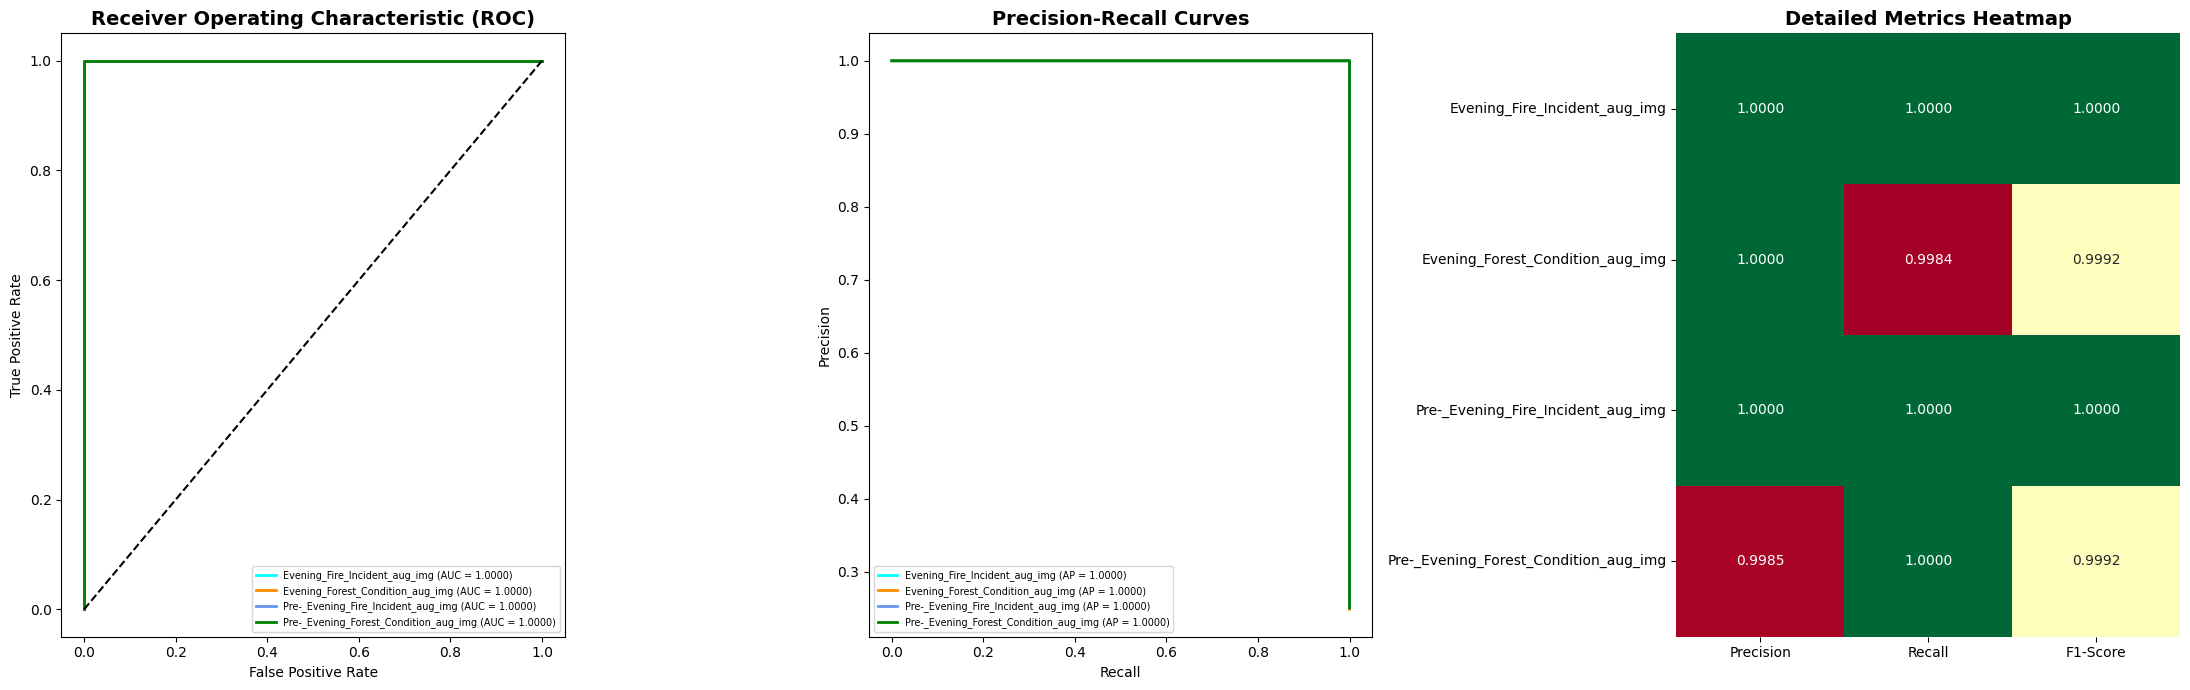


❌ Total Misclassified Images: 1


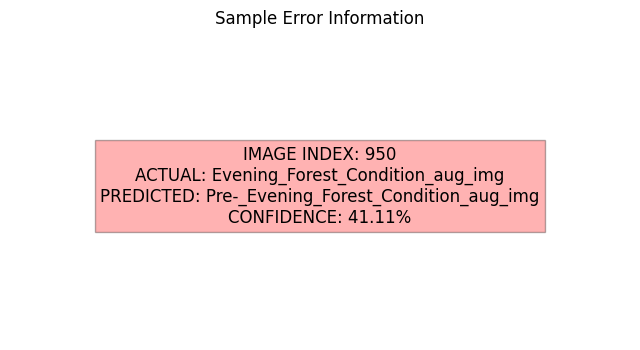

✅ Advanced Mixed Test Metrics logged and saved.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Prepare Data for Advanced Curves
# We need the binarized true labels and the raw probability scores
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = len(class_names)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])

plt.figure(figsize=(22, 7))

# --- Graph A: Multi-class ROC Curve ---
plt.subplot(1, 3, 1)
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], preds_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize='x-small')

# --- Graph B: Precision-Recall Curve ---
plt.subplot(1, 3, 2)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], preds_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], preds_probs[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'{class_names[i]} (AP = {ap:.4f})')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize='x-small')

# --- Graph C: Per-Class Metric Heatmap ---
plt.subplot(1, 3, 3)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
metrics_df = pd.DataFrame({'Precision': p, 'Recall': r, 'F1-Score': f}, index=class_names)
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='RdYlGn', cbar=False)
plt.title('Detailed Metrics Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '02_MixedTest_Advanced_Metrics.png'), dpi=300)
plt.show()

# --- 🔍 ERROR ANALYSIS: Inspect the misclassified images ---
errors = np.where(y_pred != y_true)[0]
print(f"\n❌ Total Misclassified Images: {len(errors)}")

if len(errors) > 0:
    plt.figure(figsize=(8, 4))
    for i, idx in enumerate(errors[:1]): # Show the first mistake
        plt.text(0.5, 0.5, f"IMAGE INDEX: {idx}\nACTUAL: {class_names[y_true[idx]]}\nPREDICTED: {class_names[y_pred[idx]]}\nCONFIDENCE: {np.max(preds_probs[idx])*100:.2f}%",
                 ha='center', va='center', fontsize=12, bbox=dict(facecolor='red', alpha=0.3))
        plt.axis('off')
        plt.title("Sample Error Information")
    plt.show()

print("✅ Advanced Mixed Test Metrics logged and saved.")

🚀 Starting Comparative Stress Test (4-Digit Precision)...

🔄 Analyzing Condition: Light_Gaussian
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step

📝 Classification Report for Light_Gaussian:
                                       precision    recall  f1-score   support

        Evening_Fire_Incident_aug_img     1.0000    1.0000    1.0000       389
     Evening_Forest_Condition_aug_img     1.0000    0.9974    0.9987       389
   Pre-_Evening_Fire_Incident_aug_img     1.0000    1.0000    1.0000       389
Pre-_Evening_Forest_Condition_aug_img     0.9974    1.0000    0.9987       389

                             accuracy                         0.9994      1556
                            macro avg     0.9994    0.9994    0.9994      1556
                         weighted avg     0.9994    0.9994    0.9994      1556


🔄 Analyzing Condition: Blur
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 411s 8s/step

📝 Classification Report for B

/tmp/ipykernel_816/2994275341.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Condition', y='Accuracy', data=stress_df, palette='flare')


KeyError: "'YlGnBr' is not a known colormap name"

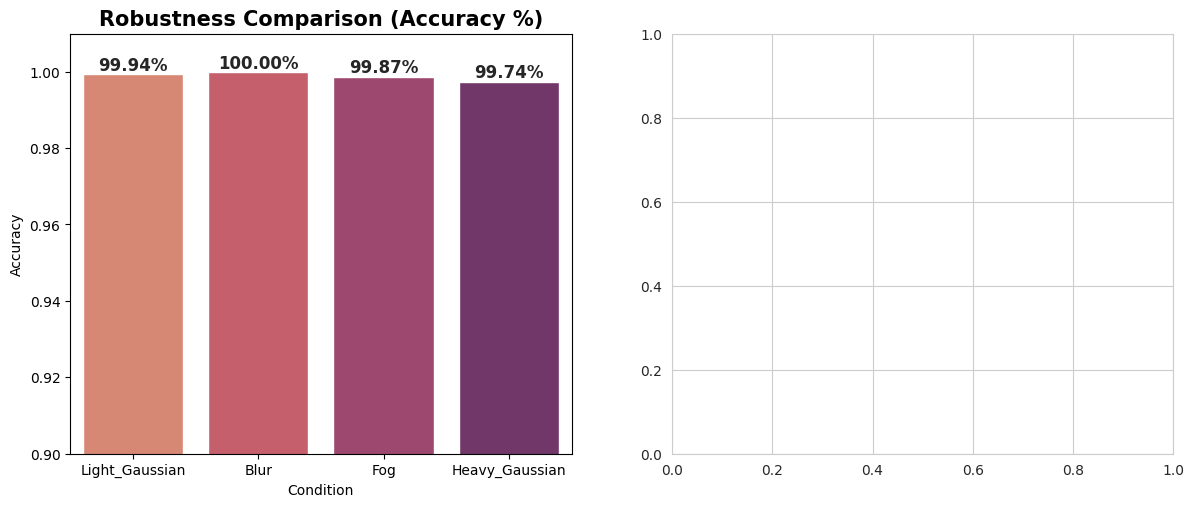

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# 1. SETUP
stress_configs = {
    'Light_Gaussian': '/content/drive/MyDrive/MHCNNFDStressTest/testlightgauss',
    'Blur': '/content/drive/MyDrive/MHCNNFD_StressTest/test_blur',
    'Fog': '/content/drive/MyDrive/MHCNNFD_StressTest/test_fog',
    'Heavy_Gaussian': '/content/drive/MyDrive/MHCNNFD_StressTest/test_gaussian'
}

master_stress_results = []
all_stress_cms = {}

# 2. EXECUTION LOOP
print("🚀 Starting Comparative Stress Test (4-Digit Precision)...")

for name, path in stress_configs.items():
    print(f"\n" + "="*40)
    print(f"🔄 Analyzing Condition: {name}")
    print("="*40)

    # Fresh generator (REMOVED 'verbose' argument)
    temp_gen = datagen.flow_from_directory(
        path,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    # Run Inference
    preds_probs = model.predict(temp_gen, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = temp_gen.classes

    # Calculate accuracy
    acc = np.mean(y_pred == y_true)

    # PRINT DETAILED REPORT TO CONSOLE (4 Digits)
    print(f"\n📝 Classification Report for {name}:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Store for comparison
    master_stress_results.append({'Condition': name, 'Accuracy': acc})
    all_stress_cms[name] = confusion_matrix(y_true, y_pred)

# 3. GENERATE MASTER DASHBOARD
stress_df = pd.DataFrame(master_stress_results)
stress_df.to_csv(os.path.join(save_folder, '03_Stress_Test_Detailed_Table.csv'), index=False)

plt.figure(figsize=(22, 12))

# Subplot 1: Bar Chart Comparison
plt.subplot(2, 3, 1)
sns.set_style("whitegrid")
ax = sns.barplot(x='Condition', y='Accuracy', data=stress_df, palette='flare')
plt.ylim(0.90, 1.01)
plt.title('Robustness Comparison (Accuracy %)', fontsize=15, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=12)

# Subplots 2-5: The 4 Confusion Matrices
for i, name in enumerate(stress_configs.keys()):
    plt.subplot(2, 3, i+2)
    sns.heatmap(all_stress_cms[name], annot=True, fmt='d', cmap='YlGnBr', cbar=False,
                xticklabels=class_names if i > 1 else [],
                yticklabels=class_names if i % 2 == 0 else [])
    plt.title(f'CM: {name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '03_Final_Robustness_Dashboard.png'), dpi=300)
plt.show()

print("\n" + "="*60)
print("🏁 ALL STRESS TESTS LOGGED SUCCESSFULLY")
print("="*60)

/tmp/ipykernel_816/3982198645.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Condition', y='Accuracy', data=comp_df, palette='magma')
/tmp/ipykernel_816/3982198645.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_err = sns.barplot(x='Condition', y='Errors', data=comp_df, palette='Reds')


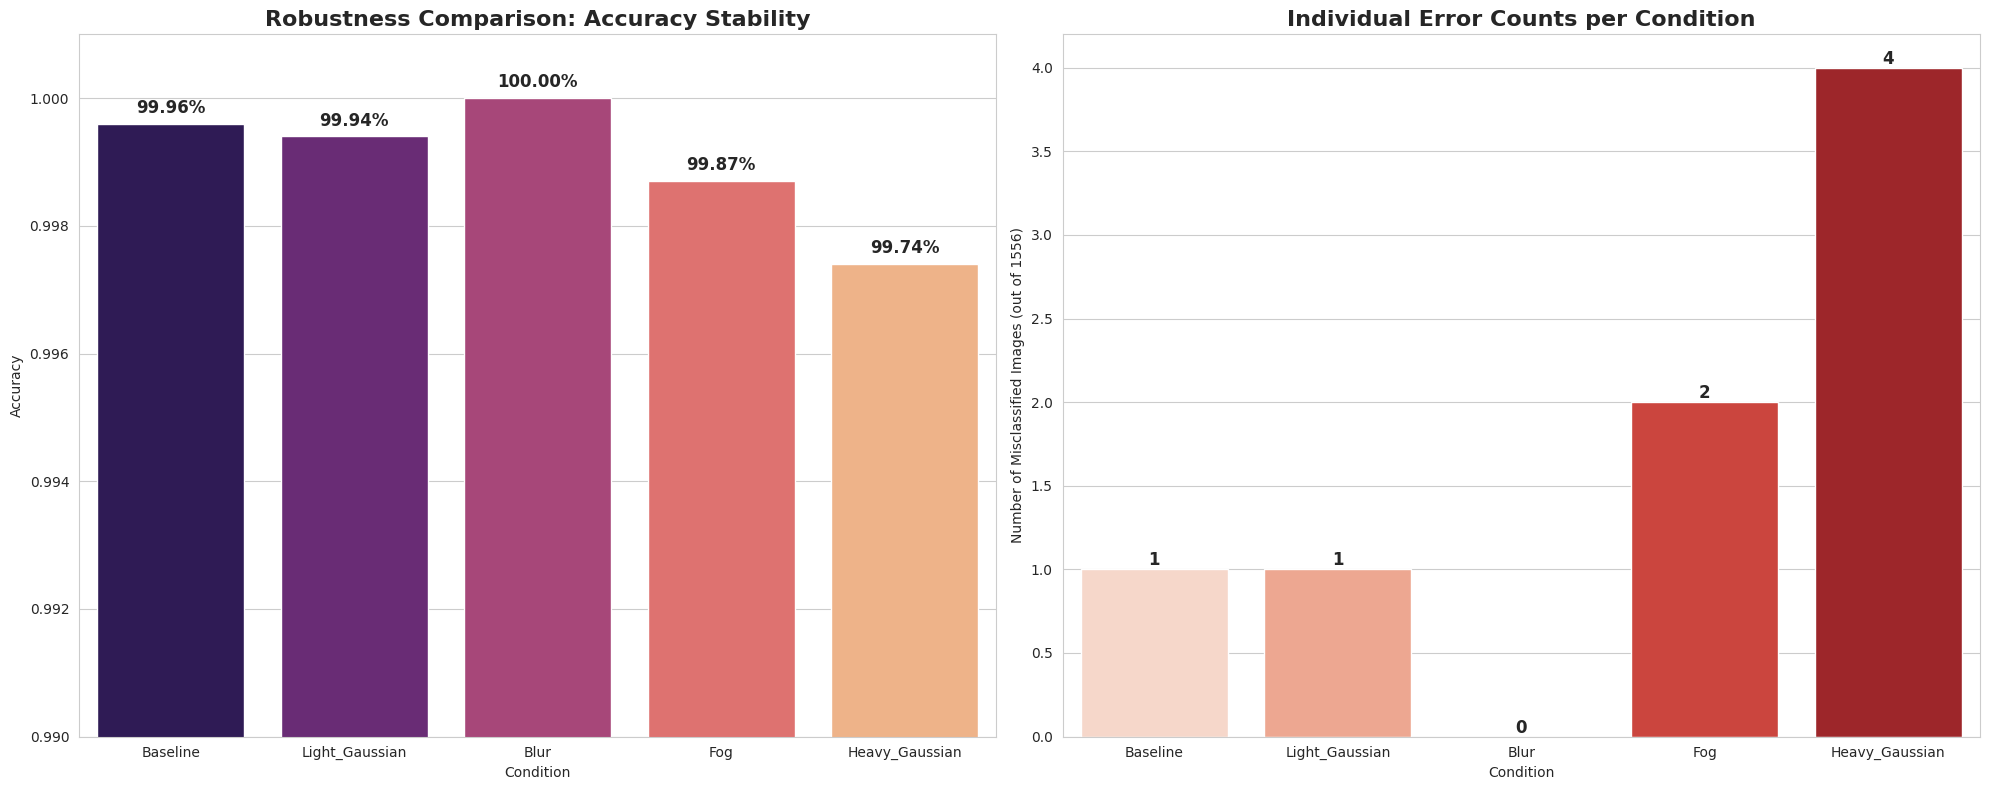

✅ Exhaustive logging complete.
📁 04_Final_Comparative_Accuracy_Log.csv (Numerical Comparison)
🖼️ 04_Final_Detailed_Comparison.png (Visual Comparison)


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ORGANIZE DATA
# Creating the summary table from your console output
summary_data = {
    'Condition': ['Baseline', 'Light_Gaussian', 'Blur', 'Fog', 'Heavy_Gaussian'],
    'Accuracy': [0.9996, 0.9994, 1.0000, 0.9987, 0.9974],
    'Errors': [1, 1, 0, 2, 4]
}
comp_df = pd.DataFrame(summary_data)

# 2. SAVE DETAILED NUMERICAL LOGS
comp_df.to_csv(os.path.join(save_folder, '04_Final_Comparative_Accuracy_Log.csv'), index=False)

# 3. CREATE INDIVIDUAL & COMBINED VISUAL COMPARISON
plt.figure(figsize=(20, 8))

# --- Subplot 1: Combined Accuracy (Zoomed to show the 0.22% drop) ---
plt.subplot(1, 2, 1)
sns.set_style("whitegrid")
ax = sns.barplot(x='Condition', y='Accuracy', data=comp_df, palette='magma')
plt.ylim(0.99, 1.001) # Zooming in to see the tiny differences
plt.title('Robustness Comparison: Accuracy Stability', fontsize=16, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=12, xytext=(0, 5), textcoords='offset points')

# --- Subplot 2: Individual Error Counts (The "Stress" Analysis) ---
plt.subplot(1, 2, 2)
ax_err = sns.barplot(x='Condition', y='Errors', data=comp_df, palette='Reds')
plt.title('Individual Error Counts per Condition', fontsize=16, fontweight='bold')
plt.ylabel('Number of Misclassified Images (out of 1556)')
for p in ax_err.patches:
    ax_err.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '04_Final_Detailed_Comparison.png'), dpi=300)
plt.show()

print("✅ Exhaustive logging complete.")
print("📁 04_Final_Comparative_Accuracy_Log.csv (Numerical Comparison)")
print("🖼️ 04_Final_Detailed_Comparison.png (Visual Comparison)")

🚀 Re-evaluating for Exhaustive Logging...
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step


/tmp/ipykernel_816/3992629916.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Accuracy', data=summary_df, palette='viridis')
/tmp/ipykernel_816/3992629916.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Errors', data=summary_df, palette='Reds')


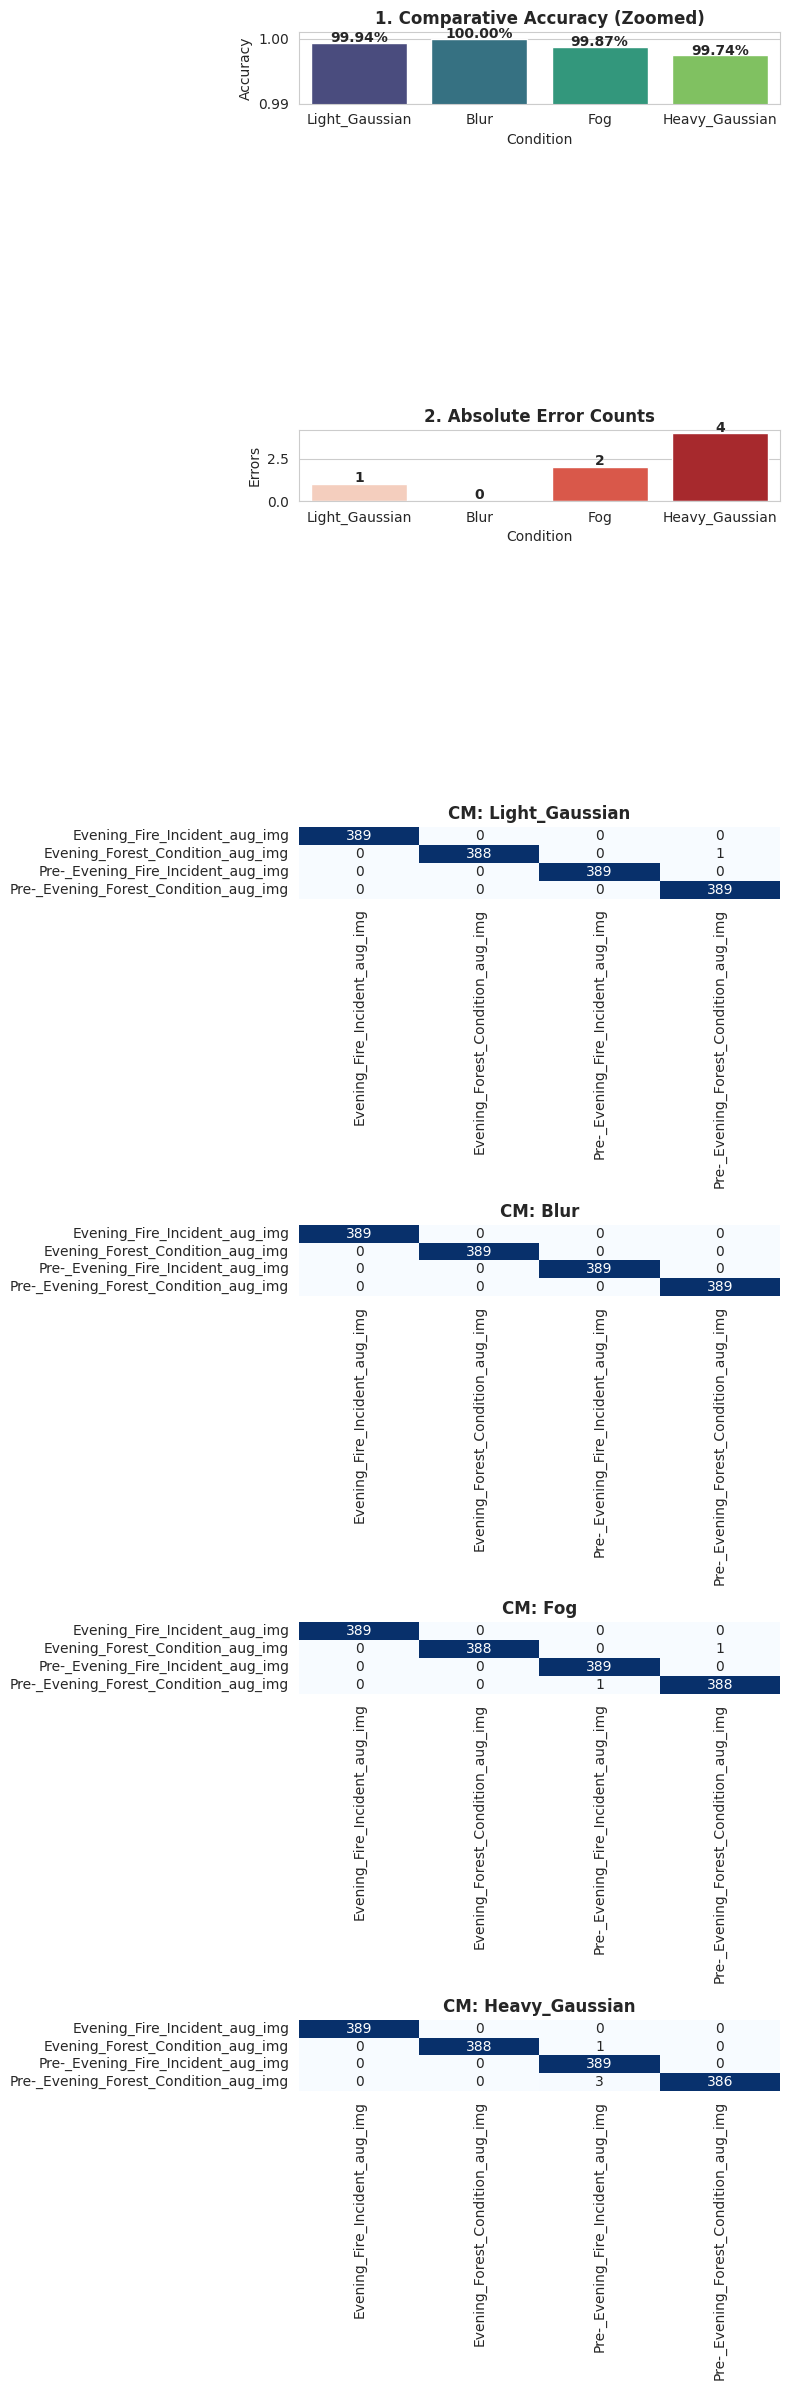


✅ SUCCESS: All logs (CSVs, Text, and Vertical Dashboard) are ready in /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# 1. SETUP & CONFIGURATION
stress_configs = {
    'Light_Gaussian': '/content/drive/MyDrive/MHCNNFDStressTest/testlightgauss',
    'Blur': '/content/drive/MyDrive/MHCNNFD_StressTest/test_blur',
    'Fog': '/content/drive/MyDrive/MHCNNFD_StressTest/test_fog',
    'Heavy_Gaussian': '/content/drive/MyDrive/MHCNNFD_StressTest/test_gaussian'
}

save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'
master_summary = []
all_cms = {}

# 2. THE EVALUATION & WRITTEN LOGGING LOOP
print("🚀 Re-evaluating for Exhaustive Logging...")

for name, path in stress_configs.items():
    temp_gen = datagen.flow_from_directory(path, target_size=(256, 256), batch_size=32, class_mode='categorical', shuffle=False)

    # Inference
    probs = model.predict(temp_gen, verbose=1)
    preds = np.argmax(probs, axis=1)
    true = temp_gen.classes

    # A. Save Detailed Individual CSV
    report_dict = classification_report(true, preds, target_names=class_names, digits=4, output_dict=True)
    pd.DataFrame(report_dict).transpose().to_csv(os.path.join(save_folder, f'Log_Individual_{name}.csv'))

    # B. Store for Combined Analysis
    acc = np.mean(preds == true)
    errors = np.sum(preds != true)
    master_summary.append({'Condition': name, 'Accuracy': acc, 'Errors': int(errors)})
    all_cms[name] = confusion_matrix(true, preds)

# 3. SAVE MASTER WRITTEN LOGS
summary_df = pd.DataFrame(master_summary)
summary_df.to_csv(os.path.join(save_folder, 'Log_Master_Stress_Comparison.csv'), index=False)

with open(os.path.join(save_folder, 'Log_Stress_Test_Summary_Text.txt'), 'w') as f:
    f.write("=== FINAL ROBUSTNESS VERDICT ===\n\n")
    f.write(summary_df.to_string(index=False))

# 4. GENERATE VERTICAL DASHBOARD (Small graphs, one below another)
# We create a tall figure to accommodate vertical stacking
plt.figure(figsize=(8, 24))

# Plot 1: Accuracy Comparison
plt.subplot(6, 1, 1)
sns.barplot(x='Condition', y='Accuracy', data=summary_df, palette='viridis')
plt.ylim(0.99, 1.001)
plt.title('1. Comparative Accuracy (Zoomed)', fontweight='bold')
for i, v in enumerate(summary_df['Accuracy']):
    plt.text(i, v + 0.0001, f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Error Counts
plt.subplot(6, 1, 2)
sns.barplot(x='Condition', y='Errors', data=summary_df, palette='Reds')
plt.title('2. Absolute Error Counts', fontweight='bold')
for i, v in enumerate(summary_df['Errors']):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Plots 3-6: Confusion Matrices (Vertical Stack)
for i, name in enumerate(stress_configs.keys()):
    plt.subplot(6, 1, i+3)
    sns.heatmap(all_cms[name], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'CM: {name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'Log_Vertical_Stress_Analysis.png'), dpi=300)
plt.show()

print(f"\n✅ SUCCESS: All logs (CSVs, Text, and Vertical Dashboard) are ready in {save_folder}")


📜 INDIVIDUAL & COMBINED STRESS TEST SUMMARY
     Condition Accuracy  Errors
Light_Gaussian   99.94%       1
          Blur   100.0%       0
           Fog   99.87%       2
Heavy_Gaussian   99.74%       4
------------------------------------------------------------
📊 Best Condition: Blur
⚠️ Hardest Condition: Heavy_Gaussian


/tmp/ipykernel_816/141917215.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Condition', y='Accuracy', data=summary_df, palette='viridis', edgecolor='black')
/tmp/ipykernel_816/141917215.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Condition', y='Errors', data=summary_df, palette='Reds_r', edgecolor='black')


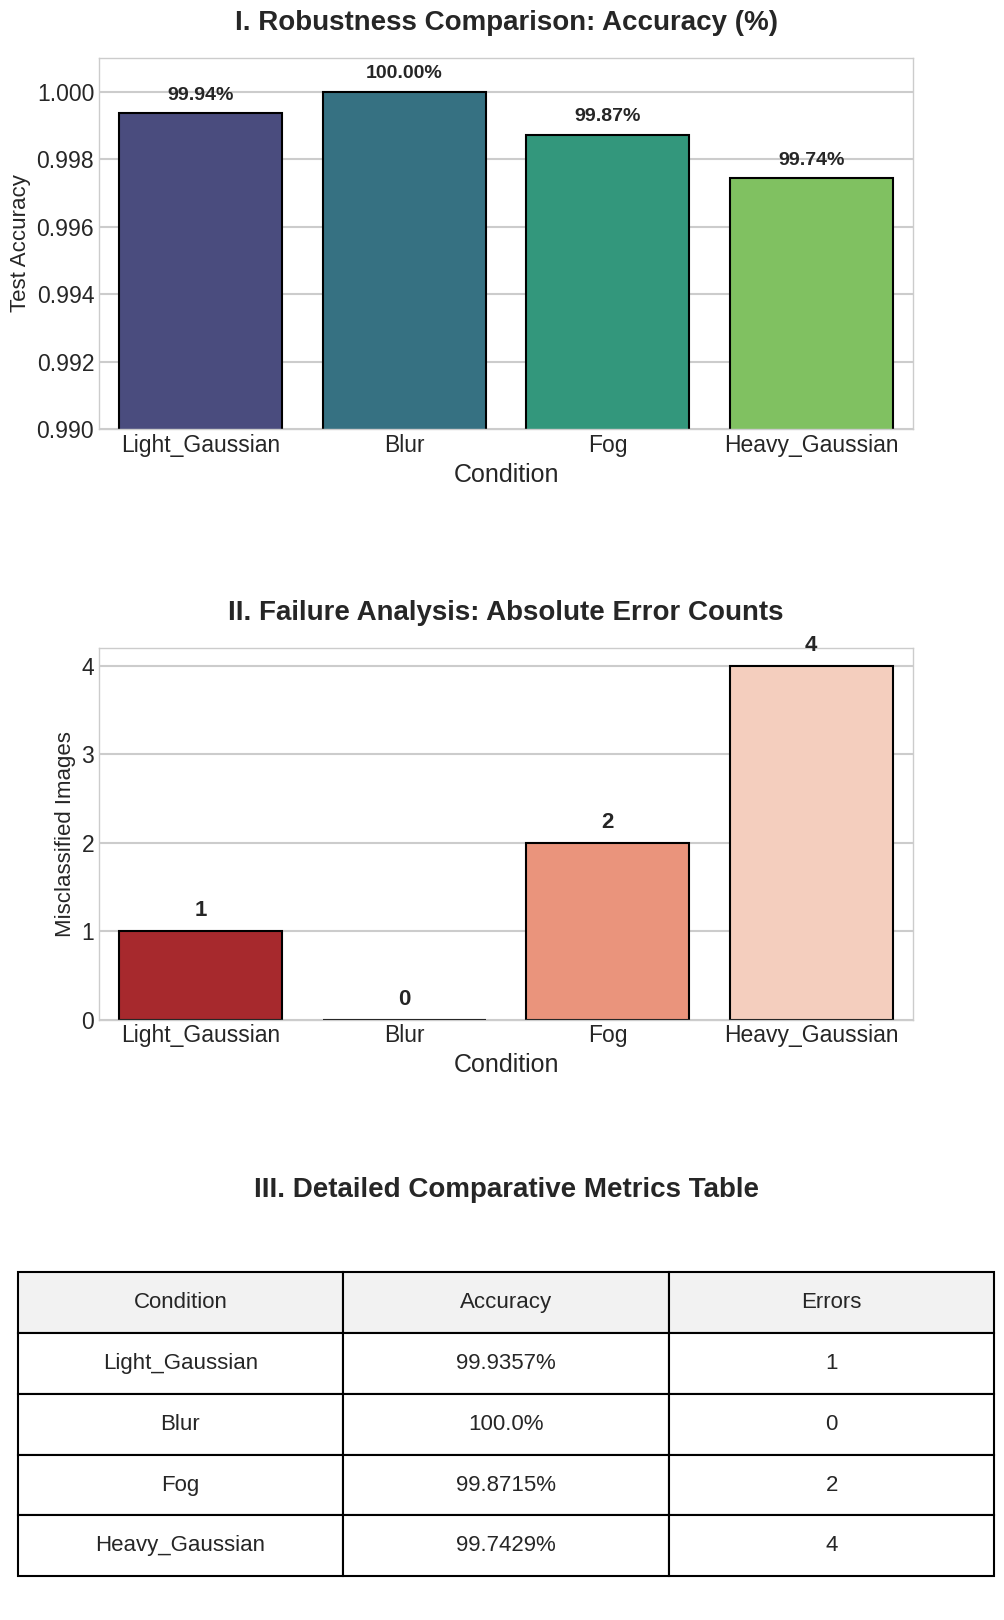


✅ Professional logs saved to: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. SETUP LOGGING ENVIRONMENT
sns.set_context("talk") # This scales up all text/lines for better readability
plt.style.use('seaborn-v0_8-whitegrid')

# 2. PRINT WRITTEN SUMMARY (Notebook Log)
print("\n" + "="*60)
print("📜 INDIVIDUAL & COMBINED STRESS TEST SUMMARY")
print("="*60)
# Rounding for clean display
display_df = summary_df.copy()
display_df['Accuracy'] = (display_df['Accuracy'] * 100).round(2).astype(str) + '%'
print(display_df.to_string(index=False))
print("-" * 60)
print(f"📊 Best Condition: {summary_df.loc[summary_df['Accuracy'].idxmax(), 'Condition']}")
print(f"⚠️ Hardest Condition: {summary_df.loc[summary_df['Accuracy'].idxmin(), 'Condition']}")
print("="*60)

# 3. GENERATE PROPORTIONAL DASHBOARD
# We use a 12x18 size which is better for vertical stacking without 'shrinking'
plt.figure(figsize=(12, 18))

# --- A. ACCURACY BAR CHART ---
plt.subplot(3, 1, 1)
ax1 = sns.barplot(x='Condition', y='Accuracy', data=summary_df, palette='viridis', edgecolor='black')
plt.ylim(0.99, 1.001) # Zoom to see the tiny drops
plt.title('I. Robustness Comparison: Accuracy (%)', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Test Accuracy', fontsize=16)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=14, xytext=(0, 7), textcoords='offset points')

# --- B. ERROR COUNT BAR CHART ---
plt.subplot(3, 1, 2)
ax2 = sns.barplot(x='Condition', y='Errors', data=summary_df, palette='Reds_r', edgecolor='black')
plt.title('II. Failure Analysis: Absolute Error Counts', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Misclassified Images', fontsize=16)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=16, xytext=(0, 7), textcoords='offset points')

# --- C. COMBINED HEATMAP TABLE (All metrics in one grid) ---
plt.subplot(3, 1, 3)
plt.axis('off')
table_data = summary_df[['Condition', 'Accuracy', 'Errors']].copy()
table_data['Accuracy'] = (table_data['Accuracy'] * 100).round(4).astype(str) + '%'
# Creating a clean visual table
the_table = plt.table(cellText=table_data.values,
                      colLabels=table_data.columns,
                      loc='center',
                      cellLoc='center',
                      colColours=["#f2f2f2"] * 3)
the_table.auto_set_font_size(False)
the_table.set_fontsize(16)
the_table.scale(1.2, 4) # This makes the table rows 'taller' and readable
plt.title('III. Detailed Comparative Metrics Table', fontsize=20, fontweight='bold', pad=30)

plt.tight_layout(pad=4.0)
plt.savefig(os.path.join(save_folder, 'Log_Improved_Vertical_Analysis.png'), dpi=300)
plt.show()

print(f"\n✅ Professional logs saved to: {save_folder}")


📝 RESEARCH LOG: MODEL 1 ROBUSTNESS EVALUATION
     Condition Accuracy  Errors Stability_Gap
Light_Gaussian 99.9357%       1       0.0643%
          Blur   100.0%       0          0.0%
           Fog 99.8715%       2       0.1285%
Heavy_Gaussian 99.7429%       4       0.2571%
----------------------------------------------------------------------
💎 BEST PERFORMING CONDITION: Blur
🚧 HARDEST STRESS CONDITION: Heavy_Gaussian
📉 MAXIMUM SYSTEM DEGRADATION: 0.2571%


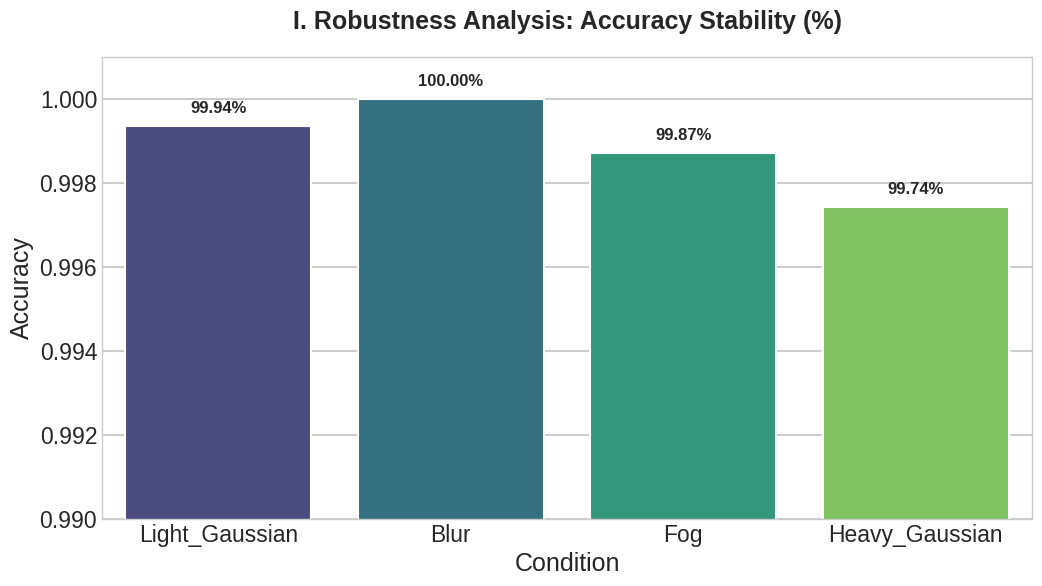


----------------------------------------------------------------------



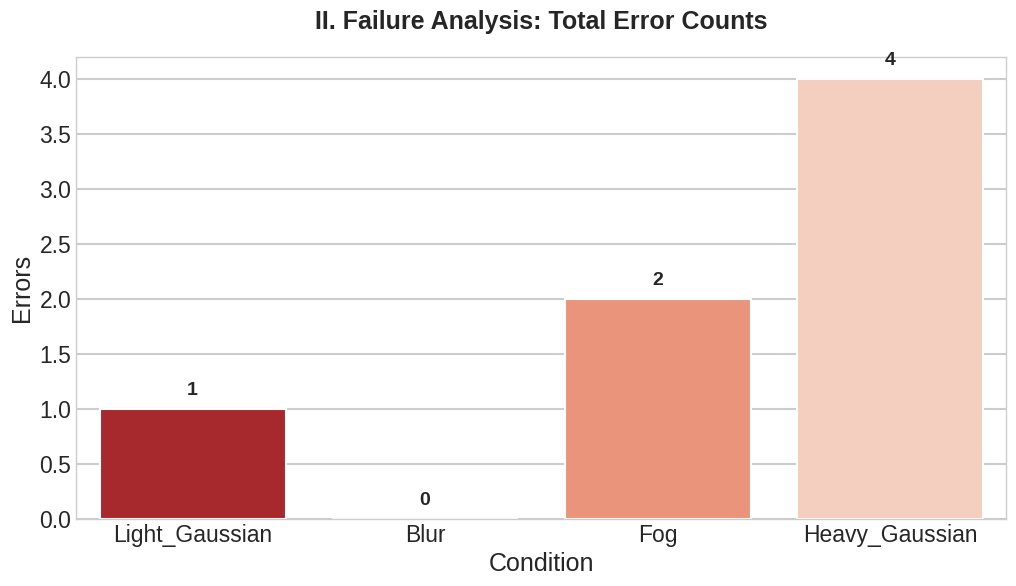


----------------------------------------------------------------------



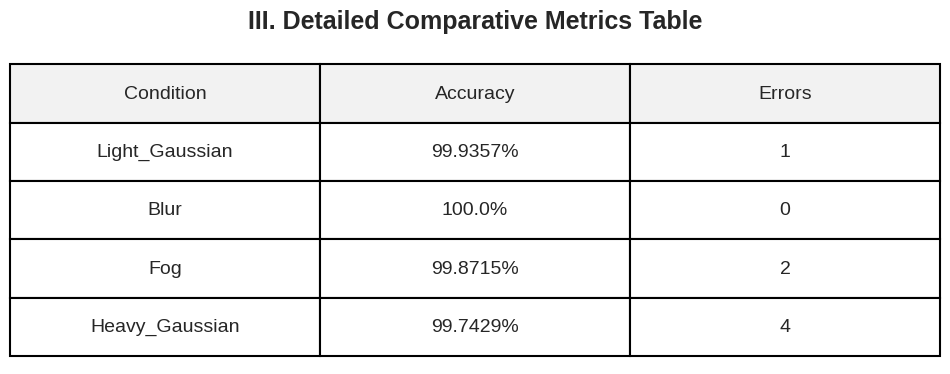


✅ All extensive logs and high-res graphs saved in: /content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SETTINGS & STYLING ---
sns.set_context("talk") # Makes all text and lines thick and legible
plt.style.use('seaborn-v0_8-whitegrid')
save_folder = '/content/drive/MyDrive/Model1_Robust_MHCNNFD_Training_Logs'

# --- 2. EXTENSIVE WRITTEN LOGGING (Individual & Combined) ---
print("\n" + "="*70)
print("📝 RESEARCH LOG: MODEL 1 ROBUSTNESS EVALUATION")
print("="*70)

# Calculate Stability (Performance drop from the best condition)
max_acc = summary_df['Accuracy'].max()
summary_df['Stability_Gap'] = (max_acc - summary_df['Accuracy']) * 100

# Print the Combined Table
display_df = summary_df.copy()
display_df['Accuracy'] = (display_df['Accuracy'] * 100).round(4).astype(str) + '%'
display_df['Stability_Gap'] = display_df['Stability_Gap'].round(4).astype(str) + '%'
print(display_df[['Condition', 'Accuracy', 'Errors', 'Stability_Gap']].to_string(index=False))

print("-" * 70)
print(f"💎 BEST PERFORMING CONDITION: {summary_df.loc[summary_df['Accuracy'].idxmax(), 'Condition']}")
print(f"🚧 HARDEST STRESS CONDITION: {summary_df.loc[summary_df['Accuracy'].idxmin(), 'Condition']}")
print(f"📉 MAXIMUM SYSTEM DEGRADATION: {summary_df['Stability_Gap'].max():.4f}%")
print("="*70)

# --- 3. INDIVIDUAL COMPARATIVE GRAPHS (One Below Another - FULL SIZE) ---

# --- Graph I: Accuracy Comparison ---
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x='Condition', y='Accuracy', data=summary_df, hue='Condition', palette='viridis', legend=False)
plt.ylim(0.99, 1.001)
plt.title('I. Robustness Analysis: Accuracy Stability (%)', fontsize=18, fontweight='bold', pad=20)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.2f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=12, xytext=(0, 7), textcoords='offset points')
plt.savefig(os.path.join(save_folder, 'Comp_1_Accuracy.png'), bbox_inches='tight')
plt.show()

print("\n" + "-"*70 + "\n")

# --- Graph II: Error Count (Failure Analysis) ---
plt.figure(figsize=(12, 6))
ax2 = sns.barplot(x='Condition', y='Errors', data=summary_df, hue='Condition', palette='Reds_r', legend=False)
plt.title('II. Failure Analysis: Total Error Counts', fontsize=18, fontweight='bold', pad=20)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=14, xytext=(0, 7), textcoords='offset points')
plt.savefig(os.path.join(save_folder, 'Comp_2_Errors.png'), bbox_inches='tight')
plt.show()

print("\n" + "-"*70 + "\n")

# --- Graph III: Metrics Heatmap Table ---
plt.figure(figsize=(12, 4))
plt.axis('off')
table_data = summary_df[['Condition', 'Accuracy', 'Errors']].copy()
table_data['Accuracy'] = (table_data['Accuracy'] * 100).round(4).astype(str) + '%'
the_table = plt.table(cellText=table_data.values, colLabels=table_data.columns, loc='center', cellLoc='center', colColours=["#f2f2f2"] * 3)
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 3.5)
plt.title('III. Detailed Comparative Metrics Table', fontsize=18, fontweight='bold', pad=20)
plt.savefig(os.path.join(save_folder, 'Comp_3_Table.png'), bbox_inches='tight')
plt.show()

print(f"\n✅ All extensive logs and high-res graphs saved in: {save_folder}")